### Initalization

In [14]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# Pointing the path to the import and parameter files
import sys
sys.path.insert(0, '../chi2_py_files/')
# Import list
from imports import *
import param as pm


from matplotlib.ticker import MaxNLocator

savegig=False

### Chi Square Method

In [31]:
##CHI SQAURE METHOD
def chisq_func2(a_param, s_param=None, damper=None, satellites_only=False, sat_info=pm.satellite_catalogue, add_sub=[True, False],
                frequency_slice=False, time_slice=False, t_mask=False, d_mask=False ,time_avg=False, 
                chi_sigma=False, verbose=False):
    
    if d_mask==False:
        satellites=None
    else:
        satellites=pm.data_save+'nearby_satellites/nearby_satellite_close_angle_'+d_mask+'.p'
    
    """INITIALIZING THE SATELLITE FUNCTION"""
    sat = ss(file_name=str(pm.file), 
                 sats_only=satellites_only, 
                 data_loc=pm.data_save, 
                 sat_loc=pm.data_save,
                 survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency], 
                 sat_info=sat_info,
                 plots_loc=pm.data_plot,
                 sat_beam=pm.beam_model+'_beam_'+str(pm.fs)+'_'+str(pm.fe)+'MHz', 
                 frequency_range=[pm.fs, pm.fe], 
                 constellations=pm.constellations_remain,
                 nearby_satellites=satellites,
                 verbose=False)
    
    """EXCECUTING THE THE SATELLITE SIM FUNCTION"""
    sat.excecute(a_param=a_param, 
                 obs_time_start=time_slice[0], obs_time_end=time_slice[1], 
                 obs_frequency_start=frequency_slice[0], obs_frequency_end=frequency_slice[1], 
                 file_bias_choice=pm.bias, 
                 add_sub=add_sub, 
                 attenuation_func=damper, 
                 attenuation_sigma=s_param, 
                 bandsize=None,
                 verbose=False)

    """FREQUENCY SLICE"""
    frange_slice = sat.frequency_band[sat.frequency_idx[0]:sat.frequency_idx[1]]  
    
    """MASKING"""
    ## TEMPERATURE MASKING 
    if t_mask!=False and d_mask==False:
        print ('Temperature mask of '+str(t_mask)+' Kelvin')
        zero_arr = np.zeros(sat.calibration_data_slice.shape)
        mask_idx = np.where(sat.calibration_data_slice > t_mask)

        zero_arr[mask_idx]=1
        simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=zero_arr.T)    #SIMULATIONS
        data = np.ma.array(data=sat.calibration_data_slice.T, mask=zero_arr.T)  #DATA

    ## DEGREE MASKING
    elif d_mask!=False and t_mask==False:
        print ("Area mask of "+str(d_mask)+" degrees")
        simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=sat.mask_nearby_satellites_slice)
        data = np.ma.array(data=sat.calibration_data_slice.T, mask=sat.mask_nearby_satellites_slice)
    
    ## NO MASKING
    else:
        print ("No masking applied")
        simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=None)
        data = np.ma.array(data=sat.calibration_data_slice.T, mask=None)
        
    """TIME AVERAGING"""
    if time_avg!=False:
        print ("Time averageing for every "+str(time_avg)+" seconds")
        #Averaging over time - MISSING TIMER PARAMETER
        data = tools.waterfall_avg_time(timer=pm.nd_s0[sat.time_idx[0]:sat.time_idx[1]], size=time_avg, waterfall=data)
        simulation = tools.waterfall_avg_time(timer=pm.nd_s0[sat.time_idx[0]:sat.time_idx[1]], size=time_avg, waterfall=simulation)
        time_idx = sat.time_idx


    
    """CHI SQAURE NUMERATOR"""
    chi_num = simulation - data  # WANT THIS VALUE

    """CHI^2 SIGMA CHOICE"""
    if chi_sigma==True:
        sig=data
        # sig=tools.radiometer_eq(data=data, n_dish=58)  # Note this is sigma (expected noise level), it must be squared to give the radiometer equation
    else: 
        sig=1
    
    """CHI SQUARE VALUE"""
    chi_sq = np.ma.sum(chi_num**2 / sig**2) 
      
    chi_sq_N = chi_sq /  np.ma.size(data)
    
    if verbose==True:
        print ("Chi numerator value: "+str(np.ma.sum(chi_num)))
        print ("Chi Square value: "+str(chi_sq))
        print ("Chi Square N value: "+str(chi_sq_N))
    
    if time_avg!=False: 
        return data, simulation, chi_sq_N, frange_slice, sat.time_idx#, sat.sat_data_adjusted
    
    else:
        return data, simulation, chi_sq_N, frange_slice#, sat.sat_data_adjusted

In [17]:
npol = 2
ndish = 58
delt = 2
delnu = 0.2*1e6

dem = npol*ndish*delt*delnu

# $\chi^2 = \dfrac{D-S}{\sigma_D^2}$

# $\sigma_D^2 = 1 $ or $\sigma_D^2 = T_{sys}(t,\nu)^2 $

# $\chi^2_{FoM} = \chi^2 /N$

In [18]:
sat_cat='/users/bengelbrecht/PhD_Work/Satellite_Code/satellite_RFI-untangle/Notebooks/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2_bw.csv'

### MASKING WITH THE GEO-SATELLITES

In [ ]:
md_loc3 = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/sat_5/degree_mask/'

degree = '5_geo'
deg_name = [r'$1^{\circ}$', r'$1^{\circ}$F', r'$5^{\circ}$', r'$5^{\circ}$F']

md_frac3 = pickle.load(open(md_loc3+'1551055211_1100-1350_774.75-6474.34_degree-'+str(degree)+'_no-dampening_fraction_v1.p','rb'))

md_resi3 = pickle.load(open(md_loc3+'1551055211_1100-1350_774.75-6474.34_degree-'+str(degree)+'_no-dampening_residual_v1.p','rb'))



In [ ]:
fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=1)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xticks(range(1, 21 + 1))


# ax.set_title(r'No mask: $\alpha$ best-fit: Scan period: 1100-1350 MHz')

ax.plot(np.arange(1,22), md_frac3['best-fit'], '-.', label=r'$\chi_{\sigma}$=$\sigma_{D}$')
ax.plot(np.arange(1,22), md_resi3['best-fit'], '-.', label=r'$\chi_{\sigma}=1$')

ax.set_xlabel(r'$\alpha$ #')
ax.set_ylabel('Best fit value')
ax.legend()
fig.tight_layout()

In [ ]:
md_sf3 = chisq_func2(a_param=md_frac3['best-fit'], s_param=None, damper=None, sat_info=sat_cat,
                      frequency_slice=[1100, 1350], time_slice=[None, None], 
                      t_mask=False, d_mask=degree, time_avg=False, chi_sigma=True, verbose=False)
  
md_sr3 = chisq_func2(a_param=md_resi3['best-fit'], s_param=None, damper=None, sat_info=sat_cat,
                      frequency_slice=[1100, 1350], time_slice=[None, None], 
                      t_mask=False, d_mask=degree, time_avg=False, chi_sigma=False, verbose=False)

f_slice = md_sr3[3]

In [ ]:
fig, axs = plt.subplots(figsize=(20, 4), ncols=2, nrows=1, sharex=True, sharey=True)

# fig.suptitle(r'No mask: Comparison fit: Scan period: 1100-1350 MHz')

ax=axs[0]
# ax.set_title(r'$\chi_{\sigma} = \sigma_{D}$')
ax.plot(md_sf3[3], np.mean(md_sf3[0], axis=0), label='Observation')
ax.plot(md_sf3[3], np.mean(md_sf3[1], axis=0), '--', label='Simulation')
ax.set_ylabel('Temperature [K]')
# ax.set_xlabel('Frequency [MHz]')
textstr = '\n'.join((
    r'$\sigma_D=\sigma_{R}$',
    r'$\chi^2_{FoM}=%.2f$' % (np.round(md_sf3[2], 2), ),))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax.legend()

ax=axs[1]
# ax.set_title(r'$\chi_{\sigma} = 1$')
ax.plot(md_sr3[3], np.ma.mean(md_sr3[0], axis=0), label='Observation')
ax.plot(md_sr3[3], np.ma.mean(md_sr3[1], axis=0), '--', label='Simulation')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [K]')
textstr = '\n'.join((
    r'$\sigma_D=1$',
    r'$\chi^2_{FoM}=%.2f$' % (np.round(md_sr3[2], 2), ),))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax.legend()
fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/no_mask_best_fit_1d.pdf')

In [ ]:
plots = [md_sr3[0][0:-1], md_sf3[1][0:-1], md_sr3[1][0:-1]]
plots_title = ['Data', r'$\chi^2_{F}$', r'$\chi^2_{R}$']
fig, axs = plt.subplots(figsize=(12, 4), nrows=1, ncols=3, sharey=True)
for i in range(3):
        ax = axs[i]

        cax = ax.imshow(plots[i], aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[-1], pm.nd_s0[0]], vmax=np.max(md_sr3[0]), vmin=np.min(md_sr3[0]))
        cbar = fig.colorbar(cax, ax=ax)
        cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)

        ax.set_title(plots_title[i])
        ax.set_ylabel('Time [sec]')
        ax.set_xlabel('Frequency [MHz]')

fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/no_mask_best_fit_2d.pdf')

### ADDING BOC(5,2.5) TO CATALOG

In [ ]:
sat_cat='/users/bengelbrecht/PhD_Work/Satellite_Code/satellite_RFI-untangle/Notebooks/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2_bw2.csv'

In [ ]:
mno_loc2 = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/sat_4/no_mask/'

mno_frac2 = pickle.load(open(mno_loc2+'1551055211_1100-1350_774.75-6474.34_no-mask_no-dampening_fraction_v1.p', 'rb'))
mno_resi2 = pickle.load(open(mno_loc2+'1551055211_1100-1350_774.75-6474.34_no-mask_no-dampening_residual_v1.p', 'rb'))

No mask simulation


In [ ]:
mno_sf2 = chisq_func2(a_param=mno_frac2['best-fit'], s_param=None, damper=None, sat_info=sat_cat,
                      frequency_slice=[1100, 1350], time_slice=[None, None], 
                      t_mask=False, d_mask=False ,time_avg=False, chi_sigma=True, verbose=False)
  
mno_sr2 = chisq_func2(a_param=mno_resi2['best-fit'], s_param=None, damper=None, sat_info=sat_cat,
                      frequency_slice=[1100, 1350], time_slice=[None, None], 
                      t_mask=False, d_mask=False ,time_avg=False, chi_sigma=False, verbose=False)

f_slice = mno_sr2[3]

In [ ]:
fig, axs = plt.subplots(figsize=(12, 4), ncols=2, nrows=1, sharex=True, sharey=True)

# fig.suptitle(r'No mask: Comparison fit: Scan period: 1100-1350 MHz')

ax=axs[0]
# ax.set_title(r'$\chi_{\sigma} = \sigma_{D}$')
ax.plot(mno_sf2[3], np.mean(mno_sf2[0], axis=0), label='Observation')
ax.plot(mno_sf2[3], np.mean(mno_sf2[1], axis=0), label='Simulation')
ax.set_ylabel('Temperature [K]')
# ax.set_xlabel('Frequency [MHz]')
textstr = '\n'.join((
    r'$\sigma_D=\sigma_{R}$',
    r'$\chi^2_{FoM}=%.2f$' % (np.round(mno_sf2[2], 2), ),))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax.legend()

ax=axs[1]
# ax.set_title(r'$\chi_{\sigma} = 1$')
ax.plot(mno_sr2[3], np.mean(mno_sr2[0], axis=0), label='Observation')
ax.plot(mno_sr2[3], np.mean(mno_sr2[1], axis=0), label='Simulation')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [K]')
textstr = '\n'.join((
    r'$\sigma_D=1$',
    r'$\chi^2_{FoM}=%.2f$' % (np.round(mno_sr2[2], 2), ),))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax.legend()
fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/no_mask_best_fit_1d.pdf')

Masking degree

In [ ]:
md_loc2 = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/sat_4/degree_mask/'

degree = ['1', '1F', '5', '5F']
deg_name = [r'$1^{\circ}$', r'$1^{\circ}$F', r'$5^{\circ}$', r'$5^{\circ}$F']

md_frac2 = [pickle.load(open(md_loc2+'1551055211_1100-1350_774.75-6474.34_degree-'+str(di)+'_no-dampening_fraction_v1.p','rb'))
           for di in degree]

md_resi2 = [pickle.load(open(md_loc2+'1551055211_1100-1350_774.75-6474.34_degree-'+str(di)+'_no-dampening_residual_v1.p','rb'))
           for di in degree]




In [ ]:
md_sf2 = [chisq_func2(a_param=md_frac2[di]['best-fit'], s_param=None, damper=None, sat_info=sat_cat, frequency_slice=[1100, 1350], time_slice=[None, None], 
                     t_mask=False, d_mask=deg ,time_avg=False, chi_sigma=True, verbose=False) for di,deg in enumerate(degree)]
  
md_sr2 = [chisq_func2(a_param=md_resi2[di]['best-fit'], s_param=None, damper=None, sat_info=sat_cat, frequency_slice=[1100, 1350], time_slice=[None, None], 
                     t_mask=False, d_mask=deg ,time_avg=False, chi_sigma=False, verbose=False) for di,deg in enumerate(degree)]

In [ ]:
fig, axs = plt.subplots(figsize=(20, 12), nrows=4, ncols=2, sharey=True)

# fig.suptitle(r'Degree mask:  Comparison fit: Scan period: 1100-1350 MHz')

for ri in range(4):
    ax=axs[ri,0]
    ax.plot(md_sf2[ri][3], np.mean(md_sf2[ri][0], axis=0), label='Observation')
    ax.plot(md_sf2[ri][3], np.mean(md_sf2[ri][1], axis=0), '--', label='Simulation')
    textstr = '\n'.join((
        r'$\sigma_D=\sigma_R$',
        r'Degree='+deg_name[ri],
        r'$\chi^2_{FoM}=%.2f$' % (np.round(md_sf2[ri][2], 2), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)
    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=\sigma_{D}$')
    if ri==3:
        ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Temperature [K]')
    ax.legend()
    
    
    
    
    ax=axs[ri,1]
    ax.plot(md_sr2[ri][3], np.mean(md_sr2[ri][0], axis=0), label='Observation')
    ax.plot(md_sr2[ri][3], np.mean(md_sr2[ri][1], axis=0), '--', label='Simulation')
    textstr = '\n'.join((
        r'$\sigma_D=1$',
        r'Degree='+deg_name[ri],
        r'$\chi^2_{FoM}=%.2f$' % (np.round(md_sr2[ri][2], 2), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)
    
    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=1$')
    if ri==3:
        ax.set_xlabel('Frequency [MHz]')
        
    ax.legend()
    


fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/deg_fitting.pdf')

## ORIGINAL IN PAPER

In [19]:
pm.file

1551055211

In [20]:
# folder='sat_10'
folder='sat_12'
# folder='sat_3'
# folder2='sat_4'

### No - Masking Simulation

In [28]:
sat_cat='/users/bengelbrecht/PhD_Work/Satellite_Code/satellite_RFI-untangle/Notebooks/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2_bw.csv'
mno_loc = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/'+str(pm.file)+'/'+folder+'/no_mask/'
file_list = os.listdir(mno_loc)
file_list.sort()
mno_frac = pickle.load(open(mno_loc+file_list[0], 'rb'))
mno_resi = pickle.load(open(mno_loc+file_list[1], 'rb'))


# sat_cat='/users/bengelbrecht/PhD_Work/Satellite_Code/satellite_RFI-untangle/Notebooks/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2_bw.csv'
# mno_loc2 = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/'+str(pm.file)+'/'+folder2+'/no_mask/'
# file_list2 = os.listdir(mno_loc2)
# file_list2.sort()
# mno_frac2 = pickle.load(open(mno_loc2+file_list2[0], 'rb'))
# mno_resi2 = pickle.load(open(mno_loc2+file_list2[1], 'rb'))

#### Best fit values

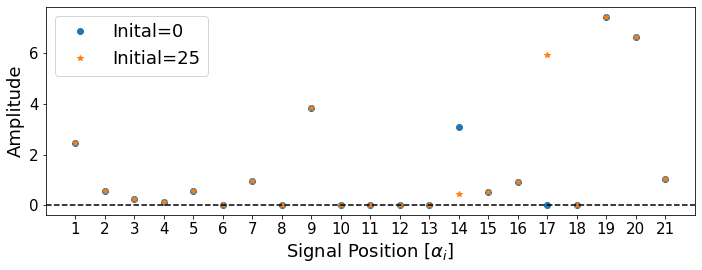

In [20]:
fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=1)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xticks(range(1, 21 + 1))


# ax.set_title(r'No mask: $\alpha$ best-fit: Scan period: 1100-1350 MHz')

ax.plot(np.arange(1,22), mno_frac['best-fit'], 'o', label=r'Inital=0')
ax.plot(np.arange(1,22), mno_frac2['best-fit'], '*', label=r'Initial=25')
ax.axhline(0, color='black', linestyle='--')

ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')
ax.set_ylabel('Amplitude')
ax.legend()
fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/nm_fitting_alpha.pdf')

In [ ]:
# fig, axs = plt.subplots(figsize=(10, 8), nrows=2, ncols=1, sharey=True)




# # ax.set_title(r'No mask: $\alpha$ best-fit: Scan period: 1100-1350 MHz')
# ax=axs[0]
# ax.plot(np.arange(1,22), mno_frac['best-fit'], 'o', label=r'$\sigma_{D}=C_1$; $\alpha_i$=1')
# ax.plot(np.arange(1,22), mno_frac2['best-fit'], 'o', alpha=0.5, label=r'$\sigma_{D}=C_1$; $\alpha_i$=0')
# ax.axhline(0, color='black', linestyle='--')
# ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# ax.set_xticks(range(1, 21 + 1))

# ax.legend()
# ax.set_ylabel('Amplitude')

# ax=axs[1]
# ax.plot(np.arange(1,22), mno_resi['best-fit'], '*', label=r'$\sigma_{D}=C_1$; $\alpha_i$=1')
# ax.plot(np.arange(1,22), mno_resi2['best-fit'], '*', alpha=0.5, label=r'$\sigma_{D}=C_1$; $\alpha_i$=0')
# ax.axhline(0, color='black', linestyle='--')
# ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# ax.set_xticks(range(1, 21 + 1))
# ax.legend()


# ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')
# ax.set_ylabel('Amplitude')
# fig.tight_layout()
# if savegig==True:
#     fig.savefig('/users/bengelbrecht/Plots/nm_fitting_alpha.pdf')

#### No-mask simulation

In [29]:
mno_sf = chisq_func2(a_param=mno_frac['best-fit'], s_param=None, damper=None, sat_info=sat_cat, frequency_slice=[1100, 1350], time_slice=[None, None], 
                     t_mask=False, d_mask=False ,time_avg=False, chi_sigma=True, verbose=False)
  
mno_sr = chisq_func2(a_param=mno_resi['best-fit'], s_param=None, damper=None, sat_info=sat_cat, frequency_slice=[1100, 1350], time_slice=[None, None], 
                     t_mask=False, d_mask=False ,time_avg=False, chi_sigma=False, verbose=False)

f_slice = mno_sr[3]

# mno_sf2 = chisq_func2(a_param=mno_frac2['best-fit'], s_param=None, damper=None, sat_info=sat_cat, frequency_slice=[1100, 1350], time_slice=[None, None], 
#                      t_mask=False, d_mask=False ,time_avg=False, chi_sigma=True, verbose=False)
  
# mno_sr2 = chisq_func2(a_param=mno_resi2['best-fit'], s_param=None, damper=None, sat_info=sat_cat, frequency_slice=[1100, 1350], time_slice=[None, None], 
#                      t_mask=False, d_mask=False ,time_avg=False, chi_sigma=False, verbose=False)

# f_slice = mno_sr[3]

No masking applied
No masking applied


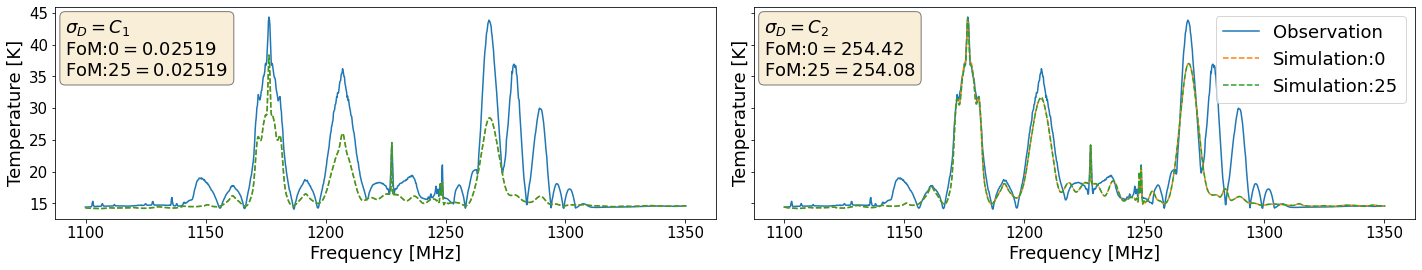

In [27]:
fig, axs = plt.subplots(figsize=(20, 4), ncols=2, nrows=1, sharex=True, sharey=True)

# fig.suptitle(r'No mask: Comparison fit: Scan period: 1100-1350 MHz')

ax=axs[0]
# ax.set_title(r'$\chi_{\sigma} = \sigma_{D}$')
ax.plot(mno_sf[3], np.mean(mno_sf[0], axis=0), label='Observation')
ax.plot(mno_sf[3], np.mean(mno_sf[1], axis=0), '--', label='Simulation:0')
ax.plot(mno_sf2[3], np.mean(mno_sf2[1], axis=0), '--', label='Simulation:25')
ax.set_ylabel('Temperature [K]')
ax.set_xlabel('Frequency [MHz]')
textstr = '\n'.join((
    r'$\sigma_D=C_1$',
    r'FoM:0$=%.5f$' % (np.round(mno_sf[2], 5), ),
    r'FoM:25$=%.5f$' % (np.round(mno_sf2[2], 5), ),))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
        verticalalignment='top', bbox=props)
# ax.legend()

ax=axs[1]
# ax.set_title(r'$\chi_{\sigma} = 1$')
ax.plot(mno_sr[3], np.mean(mno_sr[0], axis=0), label='Observation')
ax.plot(mno_sr[3], np.mean(mno_sr[1], axis=0), '--', label='Simulation:0')
ax.plot(mno_sr2[3], np.mean(mno_sr2[1], axis=0), '--', label='Simulation:25')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [K]')
textstr = '\n'.join((
    r'$\sigma_D=C_2$',
    r'FoM:0$=%.2f$' % (np.round(mno_sr[2], 2), ),
    r'FoM:25$=%.2f$' % (np.round(mno_sr2[2], 2), ),))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
        verticalalignment='top', bbox=props)
ax.legend(loc='upper right')
fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/no_mask_best_fit_1d.pdf')

In [ ]:
# fig, axs = plt.subplots(figsize=(20, 4), ncols=2, nrows=1, sharex=True, sharey=True)

# # fig.suptitle(r'No mask: Comparison fit: Scan period: 1100-1350 MHz')

# ax=axs[0]
# # ax.set_title(r'$\chi_{\sigma} = \sigma_{D}$')
# ax.plot(mno_sf[3], np.mean(mno_sf[0], axis=0), label='Observation')
# ax.plot(mno_sf[3], np.mean(mno_sf[1], axis=0), '--', label='Simulation')
# ax.set_ylabel('Temperature [K]')
# ax.set_xlabel('Frequency [MHz]')
# textstr = '\n'.join((
#     r'$\sigma_D=C_1$',
#     r'FoM$=%.5f$' % (np.round(mno_sf[2], 5), ),))

# props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# # place a text box in upper left in axes coords
# ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
#         verticalalignment='top', bbox=props)
# # ax.legend()

# ax=axs[1]
# # ax.set_title(r'$\chi_{\sigma} = 1$')
# ax.plot(mno_sr[3], np.mean(mno_sr[0], axis=0), label='Observation')
# ax.plot(mno_sr[3], np.mean(mno_sr[1], axis=0), '--', label='Simulation')
# ax.set_xlabel('Frequency [MHz]')
# ax.set_ylabel('Temperature [K]')
# textstr = '\n'.join((
#     r'$\sigma_D=C_2$',
#     r'FoM$=%.2f$' % (np.round(mno_sr[2], 2), ),))

# props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# # place a text box in upper left in axes coords
# ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
#         verticalalignment='top', bbox=props)
# ax.legend()
# fig.tight_layout()
# if savegig==True:
#     fig.savefig('/users/bengelbrecht/Plots/no_mask_best_fit_1d.pdf')

In [ ]:
plots = [mno_sr[0], mno_sf[1], mno_sr[1]]
plots_title = ['Observation', r'$C_1$', r'$C_2$']
fig, axs = plt.subplots(figsize=(12, 4), nrows=1, ncols=3, sharey=True)
for i in range(3):
        ax = axs[i]

        cax = ax.imshow(plots[i], aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[-1], pm.nd_s0[0]], vmax=np.max(mno_sr[0]), vmin=np.min(mno_sr[0]))
        cbar = fig.colorbar(cax, ax=ax)
        cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)

        ax.set_title(plots_title[i])
        ax.set_ylabel('Time [sec]')
        ax.set_xlabel('Frequency [MHz]')

fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/no_mask_best_fit_2d.pdf')

#### Plotting frequency of satellite emission

In [ ]:
tidx1 = tools.find_idx(data_array=pm.nd_s0, data_variable=2500)
tidx2 = tools.find_idx(data_array=pm.nd_s0, data_variable=3100)

In [ ]:
fidx = tools.find_idx(data_array=f_slice, data_variable=1176.45)

In [ ]:
fig, axs = plt.subplots(figsize=(10, 4), ncols=2)

ax=axs[0]
cax = ax.imshow(mno_sr[0][tidx1:tidx2, fidx-10:fidx+10], aspect='auto', extent=[f_slice[fidx-10], f_slice[fidx+10], 
                                                                           pm.nd_s0[tidx2], pm.nd_s0[tidx1]])
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
ax.set_ylabel('Time [sec]')
ax.set_xlabel('Frequency [MHz]')
ax.set_title(plots_title[0])



ax=axs[1]
cax = ax.imshow(mno_sr[1][tidx1:tidx2, fidx-10:fidx+10], aspect='auto', extent=[f_slice[fidx-10], f_slice[fidx+10], 
                                                                           pm.nd_s0[tidx2], pm.nd_s0[tidx1]])
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
ax.set_ylabel('Time [sec]')
ax.set_xlabel('Frequency [MHz]')
ax.set_title(plots_title[1])

fig.tight_layout()

In [ ]:
fig, axs = plt.subplots(figsize=(10,8), nrows=2, sharex=True)

ax=axs[0]
ax.plot(pm.nd_s0[:-1], np.ma.mean(mno_sr[0][:, fidx:fidx+1], axis=1), label='GSAT 8 @ 1176.45MHz')
ax.plot(pm.nd_s0[:-1], np.ma.mean(mno_sf[1][:, fidx:fidx+1], axis=1), alpha=0.7, label='C1')
ax.set_ylabel('Temperature [K]')
ax.legend(ncol=2, frameon=True, loc='upper right', fontsize=14)

ax=axs[1]
ax.plot(pm.nd_s0[:-1], mno_sr[0][:, fidx], label='GSAT 8 @ 1176.45MHz')
ax.plot(pm.nd_s0[:-1], mno_sr[1][:, fidx], alpha=0.7, color='r', label='C2')
ax.set_ylabel('Temperature [K]')
ax.set_xlabel('Time [sec]')
ax.legend(ncol=2, frameon=True, loc='upper right', fontsize=14)


#### Plotting with respect to distance

In [ ]:
mno_sr_resi = mno_sr[0] #/ mno_sr[1]
fslice = mno_sr[3]

# f_val = 1278.6
# f_val = 1202.1
f_val = 1248.4

f_id = np.ma.where(fslice>f_val)[0][0]
print (f_id)
size = 1
f_sub = fslice[f_id-size:f_id+size]
print (f_sub)


In [ ]:
mno_sr_resi2 = np.ma.mean(mno_sr_resi[:, f_id-size:f_id+size], axis=1)

#### Angular seperation in times

In [ ]:
sats_5deg = pickle.load(open(pm.data_save+'nearby_satellites/sats_under_5.p','rb'), encoding='latin1')

In [ ]:
print(sats_5deg.keys())
print(sats_5deg['sat_names'])

In [ ]:
sat_key = 2

In [ ]:
fig, axs = plt.subplots(figsize=(12, 8), ncols=1, nrows=2, sharex=False, sharey=False)

# fig.suptitle(r'No mask: Comparison fit: Scan period: 1100-1350 MHz')

ax=axs[0]
# ax.set_title(r'$\chi_{\sigma} = \sigma_{D}$')
ax.plot(pm.nd_s0_coords2[0][:-1], mno_sr_resi2, label=r'$\nu$ range: '+str(f_sub[0])+'-'+str(f_sub[-1])+' MHz')
ax.set_ylabel('Fractional Residual [K]')
ax.set_xlabel('RA [Deg]')

textstr = '\n'.join((
    r'GLONAAS',
    r'Name: '+sats_5deg['sat_names'][sat_key],))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax.legend()

ax=axs[1]
# ax.set_title(r'$\chi_{\sigma} = 1$')
ax.plot(sats_5deg['angle_sep'][sat_key][:-1], mno_sr_resi2,)
ax.set_ylabel('Fractional Residual [K]')
ax.set_xlabel(r'$\phi_{2}$-Seperation angle [Deg]')

fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/no_mask_best_fit_1d.pdf')

In [ ]:
fig, axs = plt.subplots(figsize=(10,8), nrows=2, sharex=True)

ax=axs[0]
ax.plot(sats_5deg['angle_sep'][sat_key][:-1], np.ma.mean(mno_sr[0][:, fidx:fidx+1], axis=1), '.', label='GSAT 8 @ 1176.45MHz')
ax.plot(sats_5deg['angle_sep'][sat_key][:-1], np.ma.mean(mno_sf[1][:, fidx:fidx+1], axis=1), '.', alpha=0.7, label='C1')
ax.set_ylabel('Temperature [K]')
ax.legend(ncol=2, frameon=True, loc='upper right', fontsize=14)

ax=axs[1]
ax.plot(sats_5deg['angle_sep'][sat_key][:-1], np.ma.mean(mno_sr[0][:, fidx:fidx+1], axis=1), '.', label='GSAT 8 @ 1176.45MHz')
ax.plot(sats_5deg['angle_sep'][sat_key][:-1], np.ma.mean(mno_sr[1][:, fidx:fidx+1], axis=1), '.', alpha=0.7, color='r', label='C2')
ax.set_ylabel('Temperature [K]')
ax.set_xlabel(r'$\phi_{2}$-Seperation angle [Deg]')
ax.legend(ncol=2, frameon=True, loc='upper right', fontsize=14)


In [ ]:
fig, axs = plt.subplots(figsize=(10,8), nrows=2, sharex=True)

ax=axs[0]
ax.plot(sats_5deg['angle_sep'][sat_key][:20], np.ma.mean(mno_sr[0][:, fidx:fidx+1], axis=1)[:20], '.', label='GSAT 8 @ 1176.45MHz')
ax.plot(sats_5deg['angle_sep'][sat_key][:20], np.ma.mean(mno_sf[1][:, fidx:fidx+1], axis=1)[:20], '.', alpha=0.7, label='C1')
ax.set_ylabel('Temperature [K]')
ax.legend(ncol=2, frameon=True, loc='upper right', fontsize=14)

ax=axs[1]
ax.plot(sats_5deg['angle_sep'][sat_key][:20], np.ma.mean(mno_sr[0][:, fidx:fidx+1], axis=1)[:20], '.', label='GSAT 8 @ 1176.45MHz')
ax.plot(sats_5deg['angle_sep'][sat_key][:20], np.ma.mean(mno_sr[1][:, fidx:fidx+1], axis=1)[:20], '.', alpha=0.7, color='r', label='C2')
ax.set_ylabel('Temperature [K]')
ax.set_xlabel(r'$\phi_{2}$-Seperation angle [Deg]')
ax.legend(ncol=2, frameon=True, loc='upper right', fontsize=14)


#### Continuing

In [ ]:
fig, axs = plt.subplots(figsize=(20, 4), ncols=2, nrows=1, sharex=True, sharey=True)

# fig.suptitle(r'No mask: Comparison fit: Scan period: 1100-1350 MHz')

ax=axs[0]
# ax.set_title(r'$\chi_{\sigma} = \sigma_{D}$')
ax.plot(mno_sf[3], np.mean(mno_sf[0], axis=0)-np.mean(mno_sf[1], axis=0), label='Observation-Simulation')
ax.set_ylabel('Temperature [K]')
# ax.set_xlabel('Frequency [MHz]')
textstr = '\n'.join((
    r'$\sigma_D=\sigma_{R}$',
    r'$\chi^2_{FoM}=%.2f$' % (np.round(mno_sf[2], 2), ),))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax.legend()

ax=axs[1]
# ax.set_title(r'$\chi_{\sigma} = 1$')
ax.plot(mno_sr[3], np.mean(mno_sr[0], axis=0)-np.mean(mno_sr[1], axis=0), label='Observation-Simulation')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [K]')
textstr = '\n'.join((
    r'$\sigma_D=1$',
    r'$\chi^2_{FoM}=%.2f$' % (np.round(mno_sr[2], 2), ),))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax.legend()
fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/no_mask_best_fit_1d.pdf')

In [ ]:
fig, axs = plt.subplots(figsize=(12, 4), ncols=2, nrows=1, sharex=True, sharey=False)

# fig.suptitle(r'No mask: Comparison fit: Scan period: 1100-1350 MHz')

ax=axs[0]
# ax.set_title(r'$\chi_{\sigma} = \sigma_{D}$')
ax.plot(f_slice, mno_sf[0][328], label='Observation')
ax.plot(f_slice, mno_sf[1][328], label=r'$C_1$')
ax.plot(f_slice, mno_sr[1][328], label=r'$C_2$')
ax.set_ylabel('Temperature [K]')
ax.set_xlabel('Frequency [MHz]')
textstr = 't='+str(np.round(pm.nd_s0[328],2))+' sec'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=18,
        verticalalignment='top', bbox=props)
ax.legend(loc='center left', prop={'size': 16})

ax=axs[1]
# ax.set_title(r'$\chi_{\sigma} = 1$')
ax.plot(f_slice, mno_sf[0][1206], label='Observation')
ax.plot(f_slice, mno_sf[1][1206], label=r'$C_1$')
ax.plot(f_slice, mno_sr[1][1206], label=r'$C_2$')
ax.set_ylabel('Temperature [K]')
ax.set_xlabel('Frequency [MHz]')
textstr = 't='+str(np.round(pm.nd_s0[1206],2))+' sec'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=18,
        verticalalignment='top', bbox=props)
# ax.legend()
fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/no_mask_best_fit_frequency_plot.pdf')

In [ ]:
gal_1 = [1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1309,
        1310, 1311, 1312, 1313, 1314, 1315, 1316]

gal_2 = [1147, 1148, 1149, 1150, 1151, 1152, 1153, 1154, 1155, 1156, 1157,
        1158, 1159, 1160, 1161, 1162, 1163, 1164, 1198, 1199, 1200, 1201,
        1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212,
        1213, 1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223,
        1301, 1302, 1303, 1304, 1305, 1306, 1307, 1308, 1309, 1310, 1311,
        1312, 1313, 1314, 1315, 1316, 1317, 1318, 1319, 1320, 1321, 1322,
        1323, 1324, 1385, 1386, 1387, 1388, 1389, 1390, 1391, 1392, 1393,
        1394, 1395, 1396, 1397, 1398]

gal_5 = [977,  978,  979,  980,  981,  982,  983,  984,  985,  986,  987,
         988,  989,  990,  991,  992,  993,  994,  995,  996,  997,  998,
         999, 1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009,
        1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020,
        1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031,
        1032, 1033, 1034, 1035, 1036, 1037, 1038, 1039, 1040, 1041, 1042,
        1043, 1044, 1045, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053,
        1054, 1055, 1128, 1129, 1130, 1131, 1132, 1133, 1134, 1135, 1136,
        1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1146, 1147,
        1148, 1149, 1150, 1151, 1152, 1153, 1154, 1155, 1156, 1157, 1158,
        1159, 1160, 1161, 1162, 1163, 1164, 1165, 1166, 1167, 1168, 1169,
        1170, 1171, 1172, 1173, 1174, 1175, 1176, 1177, 1178, 1179, 1180,
        1181, 1182, 1183, 1184, 1185, 1186, 1187, 1188, 1189, 1190, 1191,
        1192, 1193, 1194, 1195, 1196, 1197, 1198, 1199, 1200, 1201, 1202,
        1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213,
        1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224,
        1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235,
        1236, 1237, 1238, 1239, 1240, 1241, 1242, 1243, 1244, 1245, 1284,
        1285, 1286, 1287, 1288, 1289, 1290, 1291, 1292, 1293, 1294, 1295,
        1296, 1297, 1298, 1299, 1300, 1301, 1302, 1303, 1304, 1305, 1306,
        1307, 1308, 1309, 1310, 1311, 1312, 1313, 1314, 1315, 1316, 1317,
        1318, 1319, 1320, 1321, 1322, 1323, 1324, 1325, 1326, 1327, 1328,
        1329, 1330, 1331, 1332, 1333, 1334, 1335, 1336, 1337, 1338, 1339,
        1340, 1361, 1362, 1363, 1364, 1365, 1366, 1367, 1368, 1369, 1370,
        1371, 1372, 1373, 1374, 1375, 1376, 1377, 1378, 1379, 1380, 1381,
        1382, 1383, 1384, 1385, 1386, 1387, 1388, 1389, 1390, 1391, 1392,
        1393, 1394, 1395, 1396, 1397, 1398, 1399, 1400, 1401, 1402, 1403,
        1404, 1405, 1406, 1407, 1408, 1409, 1410, 1411, 1412, 1413, 1414,
        1415, 1416, 1417, 1418, 1419, 1420, 1421, 1422, 1423, 1424, 1446,
        1447, 1448, 1449, 1450, 1451, 1452, 1453, 1454, 1455, 1456, 1457,
        1458, 1459, 1460, 1461, 1462, 1463, 1464, 1465, 1466, 1467, 1468,
        1469, 1470, 1471, 1472, 1473, 1474, 1475, 1476, 1477, 1478, 1479,
        1480, 1481, 1482, 1483, 1484, 1485, 1486, 1487, 1488, 1489, 1490,
        1491, 1492, 1493, 1555, 1556, 1557, 1558, 1559, 1560, 1561, 1562,
        1563, 1564, 1565, 1566, 1567, 1568, 1569, 1570, 1571, 1572, 1573,
        1574, 1575, 1576, 1577, 1578, 1579, 1580, 1581, 1582, 1583, 1584,
        1585, 1586, 1587, 1588, 1589, 1590, 1591, 1621, 1622, 1623, 1624,
        1625, 1626, 1627, 1628, 1629, 1630, 1631, 1632]

In [ ]:


glo_1 = [328, 329, 330, 331, 332, 333, 334, 335, 346]

glo_2 = [321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333,
        334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346,
        347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357]

glo_5 = [155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
        168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180,
        181, 182, 183, 184, 185, 186, 187, 304, 305, 306, 307, 308, 309,
        310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322,
        323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335,
        336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348,
        349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361,
        362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374,
        375, 376, 377, 378, 379, 380, 462, 463, 464, 465, 466, 467, 468,
        469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481,
        482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494,
        495, 496, 497, 498, 499, 500, 501, 502, 503, 514, 515, 516, 517,
        518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530,
        531, 532, 533, 534, 535, 536, 537, 538, 539, 540, 541, 542, 543,
        544, 545, 546, 547]

In [ ]:
fig, axs = plt.subplots(figsize=(12, 5), ncols=1, nrows=2, sharex=False, sharey=True)

# fig.suptitle(r'No mask: Comparison fit: Scan period: 1100-1350 MHz')



ax=axs[0]
ax.plot(pm.nd_s0[0:-1], (mno_sr[0][:, 710]), '.', label='Observation')
ax.plot(pm.nd_s0[0:-1], (mno_sr[1][:, 710]), '-', label=r'$C_2$')

ax.plot(pm.nd_s0[glo_5], (mno_sr[0][glo_5, 710]), 'm.', label=r'$\phi_2 \leq 5^{\circ}$')
ax.plot(pm.nd_s0[glo_2], (mno_sr[0][glo_2, 710]), 'g.', label=r'$\phi_2 \leq 2^{\circ}$')
ax.plot(pm.nd_s0[glo_1], (mno_sr[0][glo_1, 710]), 'r.', label=r'$\phi_2 \leq 1^{\circ}$')

ax.legend(frameon=True, loc='upper center', ncol=3,  bbox_to_anchor=(0.72, 1.0), prop={'size':16})

ax.set_xlim(1000, 3000)
ax.set_ylabel('Temperature [K]')

textstr = r'$\nu$='+str(np.round(f_slice[710],2))+' MHz'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.93, textstr, transform=ax.transAxes, fontsize=18,
        verticalalignment='top', bbox=props)




ax=axs[1]
ax.plot(pm.nd_s0[0:-1], (mno_sr[0][:, 855]), '.')
ax.plot(pm.nd_s0[0:-1], (mno_sr[1][:, 855]), '-')
ax.plot(pm.nd_s0[gal_5], (mno_sr[0][gal_5, 855]), 'm.')
ax.plot(pm.nd_s0[gal_2], (mno_sr[0][gal_2, 855]), 'g.')
ax.plot(pm.nd_s0[gal_1], (mno_sr[0][gal_1, 855]), 'r.')

ax.set_xlim(3000, 5000)
ax.set_ylabel('Temperature [K]')
ax.set_xlabel('Time [sec]')

textstr = r'$\nu$='+str(np.round(f_slice[855],2))+' MHz'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.93, textstr, transform=ax.transAxes, fontsize=18,
        verticalalignment='top', bbox=props)


fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/no_mask_best_fit_temporal_plot.pdf')

#### Showing the evolution of the angular seperation

In [ ]:
ang_sat_idx = [np.array([ 155,  156,  157,  158,  159,  160,  180,  181,  182,  183,  184,
         185,  186,  187,  304,  305,  306,  307,  308,  309,  373,  374,
         375,  376,  377,  378,  379,  380,  462,  463,  464,  465,  466,
         467,  468,  469,  470,  495,  496,  497,  498,  499,  500,  501,
         502,  503,  514,  515,  516,  517,  518,  519,  520,  521,  522,
         523,  524,  525,  526,  527,  528,  529,  530,  531,  532,  533,
         534,  535,  536,  537,  538,  539,  540,  541,  542,  543,  544,
         545,  546,  547,  977,  978,  979,  980,  981,  982,  983,  984,
        1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053, 1054, 1055, 1128,
        1129, 1130, 1131, 1132, 1179, 1180, 1181, 1182, 1183, 1239, 1240,
        1241, 1242, 1243, 1244, 1245, 1284, 1285, 1286, 1287, 1288, 1289,
        1336, 1337, 1338, 1339, 1340, 1361, 1362, 1363, 1364, 1365, 1366,
        1367, 1368, 1417, 1418, 1419, 1420, 1421, 1422, 1423, 1424, 1446,
        1447, 1448, 1449, 1450, 1451, 1452, 1486, 1487, 1488, 1489, 1490,
        1491, 1492, 1493, 1555, 1556, 1557, 1558, 1559, 1560, 1561, 1562,
        1563, 1564, 1565, 1566, 1567, 1568, 1569, 1570, 1571, 1572, 1573,
        1574, 1575, 1576, 1577, 1578, 1579, 1580, 1581, 1582, 1583, 1584,
        1585, 1586, 1587, 1588, 1589, 1590, 1591, 1621, 1622, 1623, 1624,
        1625, 1626, 1627, 1628, 1629, 1630, 1631, 1632]),
 np.array([ 161,  162,  163,  164,  165,  166,  171,  172,  173,  174,  175,
         176,  177,  178,  179,  310,  311,  312,  313,  314,  365,  366,
         367,  368,  369,  370,  371,  372,  471,  472,  473,  474,  475,
         476,  477,  478,  479,  480,  481,  482,  483,  484,  485,  486,
         487,  488,  489,  490,  491,  492,  493,  494,  985,  986,  987,
         988,  989,  990,  991,  992,  993,  994,  995,  996,  997,  998,
         999, 1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009,
        1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020,
        1021, 1034, 1035, 1036, 1037, 1038, 1039, 1040, 1041, 1042, 1043,
        1044, 1045, 1133, 1134, 1135, 1136, 1137, 1138, 1172, 1173, 1174,
        1175, 1176, 1177, 1178, 1184, 1185, 1186, 1187, 1188, 1189, 1190,
        1232, 1233, 1234, 1235, 1236, 1237, 1238, 1290, 1291, 1292, 1293,
        1294, 1330, 1331, 1332, 1333, 1334, 1335, 1369, 1370, 1371, 1372,
        1373, 1374, 1375, 1376, 1409, 1410, 1411, 1412, 1413, 1414, 1415,
        1416, 1453, 1454, 1455, 1456, 1457, 1458, 1459, 1460, 1461, 1476,
        1477, 1478, 1479, 1480, 1481, 1482, 1483, 1484, 1485]),
 np.array([ 167,  168,  169,  170,  315,  316,  317,  318,  319,  320,  358,
         359,  360,  361,  362,  363,  364, 1022, 1023, 1024, 1025, 1026,
        1027, 1028, 1029, 1030, 1031, 1032, 1033, 1139, 1140, 1141, 1142,
        1143, 1144, 1145, 1146, 1165, 1166, 1167, 1168, 1169, 1170, 1171,
        1191, 1192, 1193, 1194, 1195, 1196, 1197, 1224, 1225, 1226, 1227,
        1228, 1229, 1230, 1231, 1295, 1296, 1297, 1298, 1299, 1300, 1325,
        1326, 1327, 1328, 1329, 1377, 1378, 1379, 1380, 1381, 1382, 1383,
        1384, 1399, 1400, 1401, 1402, 1403, 1404, 1405, 1406, 1407, 1408,
        1462, 1463, 1464, 1465, 1466, 1467, 1468, 1469, 1470, 1471, 1472,
        1473, 1474, 1475]),
 np.array([ 321,  322,  323,  324,  325,  326,  327,  336,  337,  338,  339,
         340,  341,  342,  343,  344,  345,  347,  348,  349,  350,  351,
         352,  353,  354,  355,  356,  357, 1147, 1148, 1149, 1150, 1151,
        1152, 1153, 1154, 1155, 1156, 1157, 1158, 1159, 1160, 1161, 1162,
        1163, 1164, 1198, 1199, 1200, 1201, 1202, 1203, 1204, 1205, 1216,
        1217, 1218, 1219, 1220, 1221, 1222, 1223, 1301, 1302, 1303, 1304,
        1305, 1306, 1307, 1308, 1317, 1318, 1319, 1320, 1321, 1322, 1323,
        1324, 1385, 1386, 1387, 1388, 1389, 1390, 1391, 1392, 1393, 1394,
        1395, 1396, 1397, 1398]),
 np.array([ 328,  329,  330,  331,  332,  333,  334,  335,  346, 1206, 1207,
        1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1309, 1310, 1311,
        1312, 1313, 1314, 1315, 1316])]

In [ ]:
fig = plt.figure(figsize=(12, 8))
plt.imshow(mno_sr[0], aspect='auto')
for lines in ang_sat_idx[0]: 
    plt.axhline(lines, ls='--', alpha=0.5)
for lines in ang_sat_idx[1]: 
    plt.axhline(lines, ls='--', alpha=0.2, color='orange')
for lines in ang_sat_idx[2]: 
    plt.axhline(lines, ls='--', alpha=0.2, color='black')
for lines in ang_sat_idx[3]: 
    plt.axhline(lines, ls='--', alpha=0.2, color='magenta')
for lines in ang_sat_idx[4]: 
    plt.axhline(lines, ls='--', alpha=0.2, color='cyan')
    
# plt.ylim(1750, 950)
# plt.xlim(150, 1000)

### Maksing-degree

In [21]:
md_loc = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/'+str(pm.file)+'/'+folder+'/degree_mask/'

degree = ['1F', '5F']
deg_name = [r'$1^{\circ}$F', r'$5^{\circ}$F']


file_list = os.listdir(md_loc)
file_list.sort()

idx = np.arange(len(file_list))
even_idx = idx[::2]
odd_idx = idx[1::2]


md_frac = [pickle.load(open(md_loc+file_list[di],'rb'))
           for di in even_idx]

md_resi = [pickle.load(open(md_loc+file_list[di],'rb'))
           for di in odd_idx]


# md_loc = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/'+str(pm.file)+'/'+folder2+'/degree_mask/'

# degree = ['1F', '5F']
# deg_name = [r'$1^{\circ}$F', r'$5^{\circ}$F']


# file_list = os.listdir(md_loc)
# file_list.sort()

# idx = np.arange(len(file_list))
# even_idx = idx[::2]
# odd_idx = idx[1::2]


# md_frac2 = [pickle.load(open(md_loc+file_list[di],'rb'))
#            for di in even_idx]

# md_resi2 = [pickle.load(open(md_loc+file_list[di],'rb'))
#            for di in odd_idx]

#### Best fit values

In [22]:
# ls = ['o', '*']

# fig, axs = plt.subplots(figsize=(10, 8), nrows=2, ncols=1, sharey=True)

# fig.suptitle(r'Degree mask 5F:'+str(pm.file))

# ax=axs[0]
# # ax.set_title(r'$\chi_{\sigma}$=$\sigma_{D}$')
# ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# ax.set_xticks(range(1, 21 + 1))
# ax.set_ylabel('Amplitude')

# textstr = '\n'.join((
#     r'$\sigma_D=C_1$', ),)

# props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# # place a text box in upper left in axes coords
# ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props)


# for di in range(len(md_frac)):
#     if di==1:
#         ax.plot(np.arange(1,22), md_frac[di]['best-fit'], ls[di], label=r'$\alpha_i$=0')
#         ax.plot(np.arange(1,22), md_frac2[di]['best-fit'], ls[di], alpha=0.5, label=r'$\alpha_i$=25')

# ax.axhline(0, color='black', linestyle='--')
# ax.legend()

# ax=axs[1]
# # ax.set_title(r'$\chi_{\sigma}$=$\sigma_{1}$')
# ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# ax.set_xticks(range(1, 21 + 1))
# ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')
# ax.set_ylabel('Amplitude')

# textstr = '\n'.join((
#     r'$\sigma_D=C_2$', ),)

# props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# # place a text box in upper left in axes coords
# ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18,
#         verticalalignment='top', bbox=props)

# for di in range(len(md_frac)):
#     if di==1:
#         ax.plot(np.arange(1,22), md_resi[di]['best-fit'], ls[di], label=r'$\alpha_i$=0')
#         ax.plot(np.arange(1,22), md_resi2[di]['best-fit'], ls[di], alpha=0.5, label=r'$\alpha_i$=25')

# ax.axhline(0, color='black', linestyle='--')

# # ax.legend()
# # ax.set_ylim(0,2)

# fig.tight_layout()
# if savegig==True:
#     fig.savefig('/users/bengelbrecht/Plots/deg_fitting_alpha.pdf')

In [24]:
# fig, axs = plt.subplots(figsize=(20, 8), nrows=2, ncols=2)

# fig.suptitle(r'Degree mask: $\alpha$ best-fit: Scan period: 1100-1350 MHz')

# for ci in range(2):
#     for ri in range(2):
#         ax=axs[ri,ci]
#         if ri==0 and ci==0:
#             val=0
#         elif ri==1 and ci==0:
#             val=1
#             ax.set_xlabel(r'$\alpha$ #')
#         elif ri==0 and ci==1:
#             val=2
#         else:
#             val=3
#             ax.set_xlabel(r'$\alpha$ #')
#         ax.set_title(r'Degree: '+degree[val])
#         ax.xaxis.set_major_locator(MaxNLocator(integer=True))
#         ax.set_xticks(range(1, 21 + 1))
#         ax.set_ylabel('Best fit value')
#         ax.plot(np.arange(1,22), md_frac[val]['best-fit'], '-.', label=r'$\chi_{\sigma}$=$\sigma_{D}$')
#         ax.plot(np.arange(1,22), md_resi[val]['best-fit'], '-.', label=r'$\chi_{\sigma}=1$')
#         ax.legend()

# fig.tight_layout()

#### Testing $T_{sats} - T_{sys}$

Swicthing off the bacground model

In [ ]:
md_sf5_sats = chisq_func2(a_param=md_frac[1]['best-fit'], s_param=None, damper=None, sat_info=sat_cat,
                          frequency_slice=[1000, 1499], time_slice=[None, None], add_sub=[False, False],
                     t_mask=False, d_mask=degree[1] ,time_avg=False, chi_sigma=True, verbose=False)

In [ ]:
f_slice = md_sf5_sats[3]
obs, sims = md_sf5_sats[0], md_sf5_sats[1]

In [ ]:
f_slice

In [ ]:
fstart,fend = np.where(f_slice>1120)[0][0], np.where(f_slice>1350)[0][0]

fmask = np.zeros((len(pm.nd_s0[0:-1]), len(f_slice)))
fmask[:, fstart:fend]=1

sims_mask = np.ma.array(sims, mask=fmask)

In [ ]:
fig, axs = plt.subplots(figsize=(12, 4), nrows=1, ncols=1, sharey=True)

ax = axs

cax = ax.imshow(sims_mask, aspect='auto', extent=[pm.fs, pm.fe, pm.nd_s0[-1], pm.nd_s0[0]])
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)

# ax.set_title(plots_title[i])
ax.set_ylabel('Time [sec]')
ax.set_xlabel('Frequency [MHz]')

fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/no_mask_best_fit_2d.pdf')

In [ ]:
fig, axs = plt.subplots(figsize=(12, 4), nrows=1, ncols=1, sharey=True)

ax = axs

plt.plot(f_slice, np.mean(sims_mask, axis=0))

# ax.set_ylim(0, 0.04)
ax.set_ylabel('Temperature [K]')
ax.set_xlabel('Frequency [MHz]')

fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/no_mask_best_fit_2d.pdf')

In [ ]:
degree

#### Masking-degree simulation

In [32]:
md_sf = [chisq_func2(a_param=md_frac[di]['best-fit'], s_param=None, damper=None, sat_info=sat_cat, frequency_slice=[1100, 1350], time_slice=[None, None], 
                     t_mask=False, d_mask=deg ,time_avg=False, chi_sigma=True, verbose=False) for di,deg in enumerate(degree)]
  
md_sr = [chisq_func2(a_param=md_resi[di]['best-fit'], s_param=None, damper=None, sat_info=sat_cat, frequency_slice=[1100, 1350], time_slice=[None, None], 
                     t_mask=False, d_mask=deg ,time_avg=False, chi_sigma=False, verbose=False) for di,deg in enumerate(degree)]

Area mask of 1F degrees
Area mask of 5F degrees
Area mask of 1F degrees
Area mask of 5F degrees


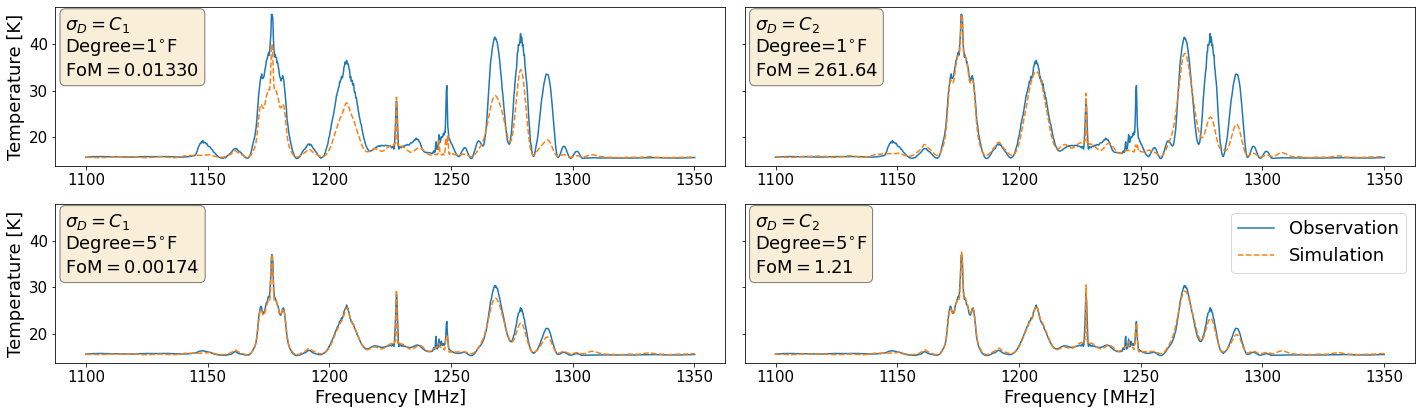

In [26]:
fig, axs = plt.subplots(figsize=(20, 6), nrows=2, ncols=2, sharey=True)

# fig.suptitle(r'Degree mask:  Comparison fit: Scan period: 1100-1350 MHz')

for ri in range(2):
    ax=axs[ri,0]
    ax.plot(md_sf[ri][3], np.mean(md_sf[ri][0], axis=0), label='Observation')
    ax.plot(md_sf[ri][3], np.mean(md_sf[ri][1], axis=0), '--', label='Simulation')
    textstr = '\n'.join((
        r'$\sigma_D=C_1$',
        r'Degree='+deg_name[ri],
        r'FoM$=%.5f$' % (np.round(md_sf[ri][2], 5), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', bbox=props)
    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=\sigma_{D}$')
    if ri==1:
        ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Temperature [K]')
    # ax.legend(loc='upper right')
    
    
    
    
    ax=axs[ri,1]
    ax.plot(md_sr[ri][3], np.mean(md_sr[ri][0], axis=0), label='Observation')
    ax.plot(md_sr[ri][3], np.mean(md_sr[ri][1], axis=0), '--', label='Simulation')
    textstr = '\n'.join((
        r'$\sigma_D=C_2$',
        r'Degree='+deg_name[ri],
        r'FoM$=%.2f$' % (np.round(md_sr[ri][2], 3), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', bbox=props)
    
    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=1$')
    if ri==1:
        ax.set_xlabel('Frequency [MHz]')
        
        ax.legend(loc='upper right')
    


fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/deg_fitting.pdf')

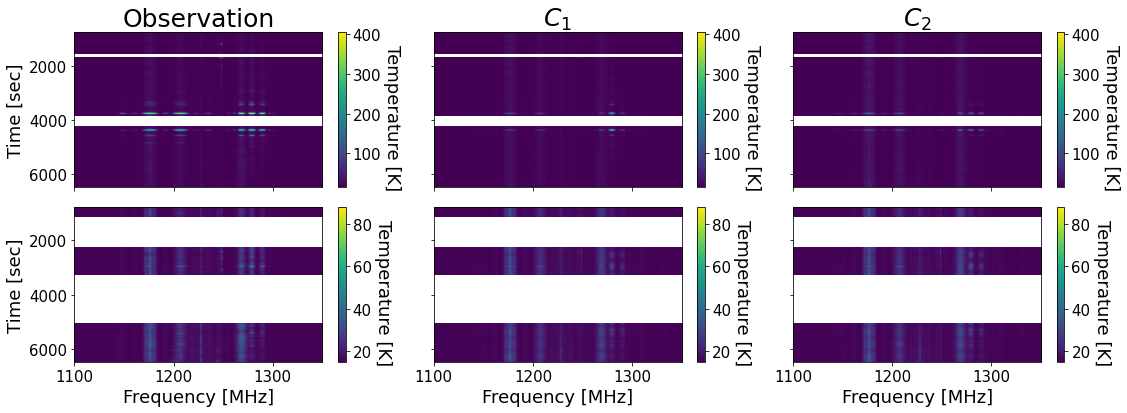

In [30]:
# plots = [mno_sr[0], mno_sf[1], mno_sr[1]]
plots_title = ['Observation', r'$C_1$', r'$C_2$']
fig, axs = plt.subplots(figsize=(16, 6), nrows=2, ncols=3, sharey=True, sharex=True)
for ri in range(2):
    for ci in range(3):
            xi = 3*ri+ci
            ax = axs[ri, ci]
            if ri==0:
                ax.set_title(plots_title[ci])

            if ci==0:
                cax = ax.imshow(md_sr[ri][0], aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[-1], pm.nd_s0[0]], vmax=np.max(md_sr[ri][0]), vmin=np.min(md_sr[ri][0]))
            elif ci==1:
                cax = ax.imshow(md_sf[ri][1], aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[-1], pm.nd_s0[0]], vmax=np.max(md_sr[ri][0]), vmin=np.min(md_sr[ri][0]))
            else:
                cax = ax.imshow(md_sr[ri][1], aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[-1], pm.nd_s0[0]], vmax=np.max(md_sr[ri][0]), vmin=np.min(md_sr[ri][0]))  
            
            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
            
            if ci==0:
                ax.set_ylabel('Time [sec]')
            if ri==1:
                ax.set_xlabel('Frequency [MHz]')

fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/deg_fitting_waterfall.pdf')

In [ ]:
fig, axs = plt.subplots(figsize=(28, 4), nrows=1, ncols=4, sharey=False)
ax=axs[0]
ax.set_title(plots_title[1])
cax = ax.imshow(md_sf[0][0] - md_sf[0][1], aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[-1], pm.nd_s0[0]], vmax=None, vmin=None)
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=15, y=0.45)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Time [sec]')

ax=axs[1]
ax.set_title(plots_title[2])
cax = ax.imshow(md_sr[0][0] - md_sr[0][1], aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[-1], pm.nd_s0[0]], vmax=None, vmin=None)
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=15, y=0.45)
ax.set_xlabel('Frequency [MHz]')

ax=axs[2]
ax.set_title(plots_title[1])
cax = ax.imshow(md_sf[1][0] - md_sf[1][1], aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[-1], pm.nd_s0[0]], vmax=None, vmin=None)
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=15, y=0.45)
ax.set_xlabel('Frequency [MHz]')

ax=axs[3]
ax.set_title(plots_title[2])
cax = ax.imshow(md_sr[1][0] - md_sr[1][1], aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[-1], pm.nd_s0[0]], vmax=None, vmin=None)
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=15, y=0.45)
ax.set_xlabel('Frequency [MHz]')


In [ ]:
fig, axs = plt.subplots(figsize=(20, 6), nrows=2, ncols=2, sharey=True)

# fig.suptitle(r'Degree mask:  Comparison fit: Scan period: 1100-1350 MHz')

for ri in range(2):
    ax=axs[ri,0]
    ax.plot(md_sf[ri][3], np.mean(md_sf[ri][0]-md_sf[ri][1], axis=0), label='Observation')
    textstr = '\n'.join((
        r'$\sigma_D=C_1$',
        r'Degree='+deg_name[ri],
        r'FoM$=%.5f$' % (np.round(md_sf[ri][2], 5), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)
    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=\sigma_{D}$')
    if ri==3:
        ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Temperature [K]')
    ax.legend()
    
    
    
    
    ax=axs[ri,1]
    ax.plot(md_sr[ri][3], np.mean(md_sr[ri][0]-md_sr[ri][1], axis=0), label='Observation')
    textstr = '\n'.join((
        r'$\sigma_D=C_2$',
        r'Degree='+deg_name[ri],
        r'FoM$=%.5f$' % (np.round(md_sr[ri][2], 5), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)
    
    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=1$')
    if ri==3:
        ax.set_xlabel('Frequency [MHz]')
        
    ax.legend()
    


fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/deg_fitting.pdf')

In [ ]:
f_val = 1248.1
# f_val = 1278.7

f_id = np.ma.where(f_slice>f_val)[0][0]
print (f_id)
size = 1
f_sub = f_slice[f_id-size:f_id+size]
print (f_sub)

In [ ]:
md_sr_resi = md_sr[1][0] / md_sr[1][1]

md_sr_resi2 = np.ma.mean(md_sr_resi[:, f_id-size:f_id+size], axis=1)

avgResult_x = np.average(sats_ang.reshape(-1, n), axis=1)
avgResult = np.ma.array([np.ma.average(md_sr_resi[:-3][0+n*i:n+n*i], axis=0) for i in range(int(2200/n))])

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

cax = ax.imshow(md_sr_resi, aspect='auto', extent=[fslice[0], fslice[-1], pm.nd_s0[-1], pm.nd_s0[0]])

cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)

In [ ]:
# fig, ax = plt.subplots(figsize=(10, 6))

# # cax = ax.imshow(md_sr_resi, aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[-1], pm.nd_s0[0]])
# ax.plot(md_sr[3][3], np.ma.mean(md_sr_resi, axis=0))
# ax.plot(md_sr[3][3], np.ma.mean(avgResult, axis=0))


In [ ]:
plt.plot(md_sr_resi2)

In [ ]:
sat_key=0

In [ ]:
fig, axs = plt.subplots(figsize=(18, 10), ncols=2, nrows=2, sharex=False, sharey=False)

# fig.suptitle(r'No mask: Comparison fit: Scan period: 1100-1350 MHz')

ax=axs[0,0]
# ax.set_title(r'$\chi_{\sigma} = \sigma_{D}$')
ax.plot(pm.nd_s0_coords2[0][:-1], md_sr_resi2, '.', label=r'$\nu$ range: '+str(f_sub[0])+'-'+str(f_sub[-1])+' MHz')
ax.set_ylabel('Fractional Residual')
ax.set_xlabel('RA [Deg]')

textstr = '\n'.join((
    r'GLONAAS',
    r'Name: '+sats_5deg['sat_names'][sat_key],))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax.legend()

ax=axs[1,0]
# ax.set_title(r'$\chi_{\sigma} = 1$')
ax.plot(sats_5deg['angle_sep'][sat_key][:-1], md_sr_resi2, '.')
ax.set_ylabel('Fractional Residual')
ax.set_xlabel(r'$\phi_{2}$-Seperation angle [Deg]')

ax=axs[1,1]
# ax.set_title(r'$\chi_{\sigma} = 1$')
ax.plot(avgResult_x, np.ma.mean(avgResult, axis=1), '.')
ax.set_ylabel('Fractional Residual')
ax.set_xlabel(r'$\phi_{2}$-Seperation angle [Deg]')

textstr = '\n'.join((
    r'10 second smoothing',))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/no_mask_best_fit_1d.pdf')

#### Checking Russian Geo-Stationary satellites

In [ ]:
russia_L = pickle.load(open('/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/nearby_satellites/nearby_geo_russian_L.p', 'rb'), encoding='latin1')

In [ ]:
fig, axs = plt.subplots(figsize=(20, 4) , nrows=1, ncols=1)
    # fig.suptitle(date+'-[GMT] constellation with respect to MeerKAT pointing', y=1.03)
ax=axs

number_of_plots=len(russia_L)
colormap = plt.cm.nipy_spectral #I suggest to use nipy_spectral, Set1,Paired
# ax.set_color_cycle([colormap(i) for i in np.linspace(0, 1,number_of_plots)])

for si in russia_L.keys():
    ax.plot(pm.nd_s0, russia_L[si],'.', label=si)
ax.axhline(0, color='red', linestyle='--', label= r'$0^\circ$')
ax.axhline(5, color='black', linestyle='--', label= r'$5^\circ$')


ax.set_xlabel('Time period [sec]')
ax.set_ylabel(r'$\phi_2$[degree]')  
ax.legend(frameon=True, loc='center', ncol=4,  bbox_to_anchor=(0.5, 1.2))


fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/geo_sats_lband_angular.pdf')

In [ ]:
np.min(russia_L['express am44'])

In [ ]:
low_t_index = np.where(russia_L['express am44'] < 1.105 )[0]

In [ ]:
low_t_index

In [ ]:
da_sim_5 = md_sr[3][0] - md_sr[3][1]

In [ ]:
fig, axs = plt.subplots(figsize=(12, 6) , nrows=1, ncols=1)
    # fig.suptitle(date+'-[GMT] constellation with respect to MeerKAT pointing', y=1.03)
ax=axs
cax = ax.imshow(da_sim_5, aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[-1], pm.nd_s0[0]])
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)

for ti in low_t_index:
    ax.axhline(pm.nd_s0[ti], color='red', linestyle='--')
    
ax.set_ylabel('Time [sec]')
ax.set_xlabel('Frequency [MHz]')

In [ ]:
t_1000 = np.where(pm.nd_s0<3000)[0]

In [ ]:
da_sim_5_small = da_sim_5[t_1000, :]

In [ ]:
fig, axs = plt.subplots(figsize=(12, 6) , nrows=1, ncols=1)
    # fig.suptitle(date+'-[GMT] constellation with respect to MeerKAT pointing', y=1.03)
ax=axs
cax = ax.imshow(da_sim_5_small, aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[t_1000[-2]], pm.nd_s0[t_1000[0]]])
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)

ax.axhline(pm.nd_s0[low_t_index[0]], color='red', linestyle='--')
ax.axhline(pm.nd_s0[low_t_index[1]], color='red', linestyle='--')

ax.set_ylabel('Time [sec]')
ax.set_xlabel('Frequency [MHz]')

In [ ]:
rvh = pickle.load(open('/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/m000_vish.p', 'rb'), encoding='latin1')

In [ ]:
rvh = rvh[pm.nd_s0_pos, :]

In [ ]:
rvh_1200 = rvh[t_1000]

In [ ]:
fidx = np.where(pm.frequency > 1520)[0][0]

In [ ]:
fig, axs = plt.subplots(figsize=(12, 6) , nrows=1, ncols=1)
    # fig.suptitle(date+'-[GMT] constellation with respect to MeerKAT pointing', y=1.03)
ax=axs
cax = ax.imshow(rvh_1200[:, fidx:], aspect='auto', extent=[pm.frequency[fidx], pm.frequency[-1], pm.nd_s0[t_1000[-2]], pm.nd_s0[t_1000[0]]])
cbar = fig.colorbar(cax, ax=ax)
# cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)

ax.axhline(pm.nd_s0[low_t_index[0]], color='red', linestyle='--', alpha = 0.3)
ax.axhline(pm.nd_s0[low_t_index[1]], color='red', linestyle='--', alpha = 0.3)
ax.axhline(pm.nd_s0[low_t_index[2]], color='red', linestyle='--', alpha = 0.3)
ax.axhline(pm.nd_s0[low_t_index[3]], color='red', linestyle='--', alpha = 0.3)
ax.axhline(pm.nd_s0[low_t_index[4]], color='red', linestyle='--', alpha = 0.3)
ax.set_ylabel('Time [sec]')
ax.set_xlabel('Frequency [MHz]')

In [ ]:
low_t_index

In [ ]:
pm.nd_s0[385]

In [ ]:
plt.plot(pm.frequency[fidx:fidx+1000], rvh_1200[47, fidx:fidx+1000])

plt.plot(pm.frequency[fidx:fidx+1000], rvh_1200[360, fidx:fidx+1000], alpha=0.5)

plt.xlim(1515, 1560)

In [ ]:
t_1000

In [ ]:

plt.plot(f_slice, da_sim_5_small[90, :])

plt.plot(f_slice, da_sim_5_small[47, :], alpha=0.5)




In [ ]:
# plt.plot(f_slice, da_sim_5_small[122, :])

plt.plot(f_slice, np.mean(da_sim_5_small[115:129, :], axis=0), alpha=0.5)


#### Comparing masking of 5 \& 5+geo mask

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=1)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xticks(range(1, 21 + 1))


# ax.set_title(r'No mask: $\alpha$ best-fit: Scan period: 1100-1350 MHz')

ax.plot(md_sf[ri][3], np.mean(md_sf[ri][0], axis=0), label='Observation')
ax.plot(md_sf[ri][3], np.mean(md_sf[ri][1], axis=0), label='Simulation')

ax.plot(np.arange(1,22), md_frac3['best-fit'], '-.', label=r'$\chi_{\sigma}$=$\sigma_{D}$')
ax.plot(np.arange(1,22), md_resi3['best-fit'], '-.', label=r'$\chi_{\sigma}=1$')

ax.set_xlabel(r'$\alpha$ #')
ax.set_ylabel('Best fit value')
ax.legend()
fig.tight_layout()

In [ ]:
fig, axs = plt.subplots(figsize=(16, 4), ncols=2, nrows=1, sharex=True, sharey=True)

# fig.suptitle(r'No mask: Comparison fit: Scan period: 1100-1350 MHz')

ax=axs[0]
# ax.set_title(r'$\chi_{\sigma} = \sigma_{D}$')
ax.plot(md_sf3[3], np.ma.mean(md_sf3[1], axis=0), label=r'Sim: 5$^{\circ}$ + geo mask ')
ax.plot(md_sf[2][3], np.ma.mean(md_sf[2][1], axis=0), label='Sim: 5$^{\circ} mask')
ax.set_ylabel('Temperature [K]')
# ax.set_xlabel('Frequency [MHz]')
textstr = '\n'.join((
    r'$\sigma_D=\sigma_{R}$',
    r'$\chi^2_{FoM}=%.2f$' % (np.round(md_sf[2][2], 2), ),))
    r'$\chi^2_{FoM}=%.2f$' % (np.round(md_sf[2][2], 2), ),))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax.legend()

ax=axs[1]
# ax.set_title(r'$\chi_{\sigma} = 1$')
ax.plot(md_sr3[3], np.ma.mean(md_sr3[1], axis=0), label=r'Sim: 5$^{\circ}$ + geo mask')
ax.plot(md_sr[2][3], np.ma.mean(md_sr[2][1], axis=0), label='Sim: 5$^{\circ}$ mask')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [K]')
textstr = '\n'.join((
    r'$\sigma_D=1$',
    r'$\chi^2_{FoM}=%.2f$' % (np.round(md_sr[2][2], 2), ),))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax.legend()
fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/no_mask_best_fit_1d.pdf')

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=1)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xticks(range(1, 21 + 1))


# ax.set_title(r'No mask: $\alpha$ best-fit: Scan period: 1100-1350 MHz')
ax.plot(np.arange(1,22), md_frac[2]['best-fit'], 'b-.', label=r'$\chi_{\sigma}$=$\sigma_{D}$, 5$^{\circ}$ mask')
ax.plot(np.arange(1,22), md_resi[2]['best-fit'], 'go-', label=r'$\chi_{\sigma}=1$, 5$^{\circ}$ mask')
ax.plot(np.arange(1,22), md_frac3['best-fit'], 'b-.', alpha=0.5, label=r'$\chi_{\sigma}$=$\sigma_{D}$, 5$^{\circ}$ + geo mask')
ax.plot(np.arange(1,22), md_resi3['best-fit'], 'go-', alpha=0.5, label=r'$\chi_{\sigma}=1$, 5$^{\circ}$ + geo mask')

ax.set_xlabel(r'$\alpha$ #')
ax.set_ylabel('Best fit value')
ax.legend()
fig.tight_layout()

### Thermal-masking

In [8]:
mt_loc = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/'+str(pm.file)+'/'+folder+'/thermal_mask/'

temperature = ['25', '50', '100']

file_list = os.listdir(mt_loc)
file_list.sort()
# Sorting even and odd index to seperate residual and fractional
idx = np.arange(len(file_list))
even_idx = idx[::2]
odd_idx = idx[1::2]

mt_frac = [pickle.load(open(mt_loc+file_list[di],'rb'))
           for di in even_idx]

mt_resi = [pickle.load(open(mt_loc+file_list[di],'rb'))
           for di in odd_idx]

#### Best fit values

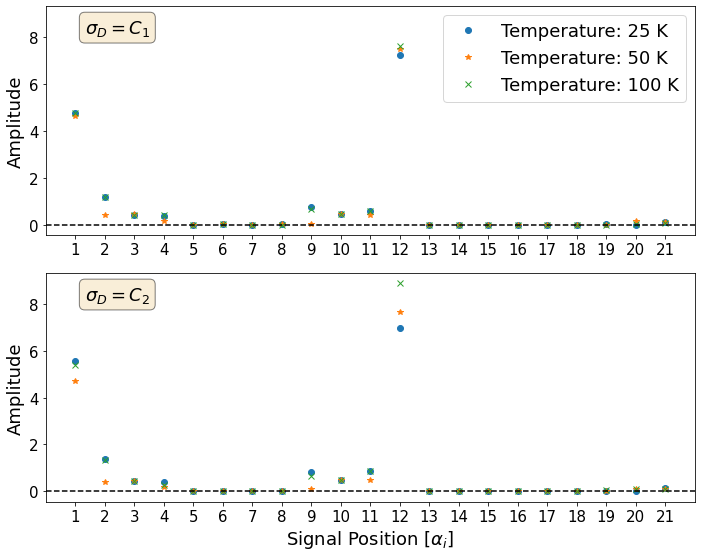

In [9]:
ls = ['o', '*', 'x']

fig, axs = plt.subplots(figsize=(10, 8), nrows=2, ncols=1, sharey=True)

# fig.suptitle(r'Degree mask: $\alpha$ best-fit: Scan period: 1100-1350 MHz')

ax=axs[0]
# ax.set_title(r'$\chi_{\sigma}$=$\sigma_{D}$')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xticks(range(1, 21 + 1))
ax.set_ylabel('Amplitude')

textstr = '\n'.join((
    r'$\sigma_D=C_1$', ),)

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18,
        verticalalignment='top', bbox=props)


for ti in range(len(mt_frac)):
    ax.plot(np.arange(1,22), mt_frac[ti]['best-fit'], ls[ti], label=r'Temperature: '+temperature[ti]+' K')
ax.axhline(0, color='black', linestyle='--')


ax.legend()

ax=axs[1]
# ax.set_title(r'$\chi_{\sigma}$=$\sigma_{1}$')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xticks(range(1, 21 + 1))
ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')
ax.set_ylabel('Amplitude')

textstr = '\n'.join((
    r'$\sigma_D=C_2$', ),)

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18,
        verticalalignment='top', bbox=props)

for ti in range(len(mt_frac)):
    ax.plot(np.arange(1,22), mt_resi[ti]['best-fit'], ls[ti], label=r'Temperature: '+temperature[ti]+' K')
ax.axhline(0, color='black', linestyle='--')

# ax.legend()
# ax.set_ylim(0,2)

fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/thermal2_fitting_alpha.pdf')

In [10]:
# fig, axs = plt.subplots(figsize=(10, 12), nrows=3, ncols=1)

# fig.suptitle(r'Thermal mask: $\alpha$ best-fit: Scan period: 1100-1350 MHz')

# for ri in range(3):
#     ax=axs[ri]
#     ax.set_title(r'Temperature: '+temperature[ri]+' K')
#     ax.xaxis.set_major_locator(MaxNLocator(integer=True))
#     ax.set_xticks(range(1, 21 + 1))
#     ax.set_ylabel('Best fit value')]
#     ax.plot(np.arange(1,22), mt_frac[ri]['best-fit'], '-.', label=r'$\chi_{\sigma}$=$\sigma_{D}$')
#     ax.plot(np.arange(1,22), mt_resi[ri]['best-fit'], '-.', label=r'$\chi_{\sigma}=1$')
#     if ri==2:
#         ax.set_xlabel(r'$\alpha$ #')
#     ax.legend()

# fig.tight_layout()

#### Masking-thermal simulation

In [11]:
mt_sf = [chisq_func2(a_param=mt_frac[ti]['best-fit'], s_param=None, damper=None, frequency_slice=[1100, 1350], time_slice=[None, None], 
                     t_mask=int(temp), d_mask=False ,time_avg=False, chi_sigma=True, verbose=False) for ti,temp in enumerate(temperature)]
  
mt_sr = [chisq_func2(a_param=mt_resi[ti]['best-fit'], s_param=None, damper=None, frequency_slice=[1100, 1350], time_slice=[None, None], 
                     t_mask=int(temp), d_mask=False ,time_avg=False, chi_sigma=False, verbose=False) for ti,temp in enumerate(temperature)]

Temperature mask of 25 Kelvin
Temperature mask of 50 Kelvin
Temperature mask of 100 Kelvin
Temperature mask of 25 Kelvin
Temperature mask of 50 Kelvin
Temperature mask of 100 Kelvin


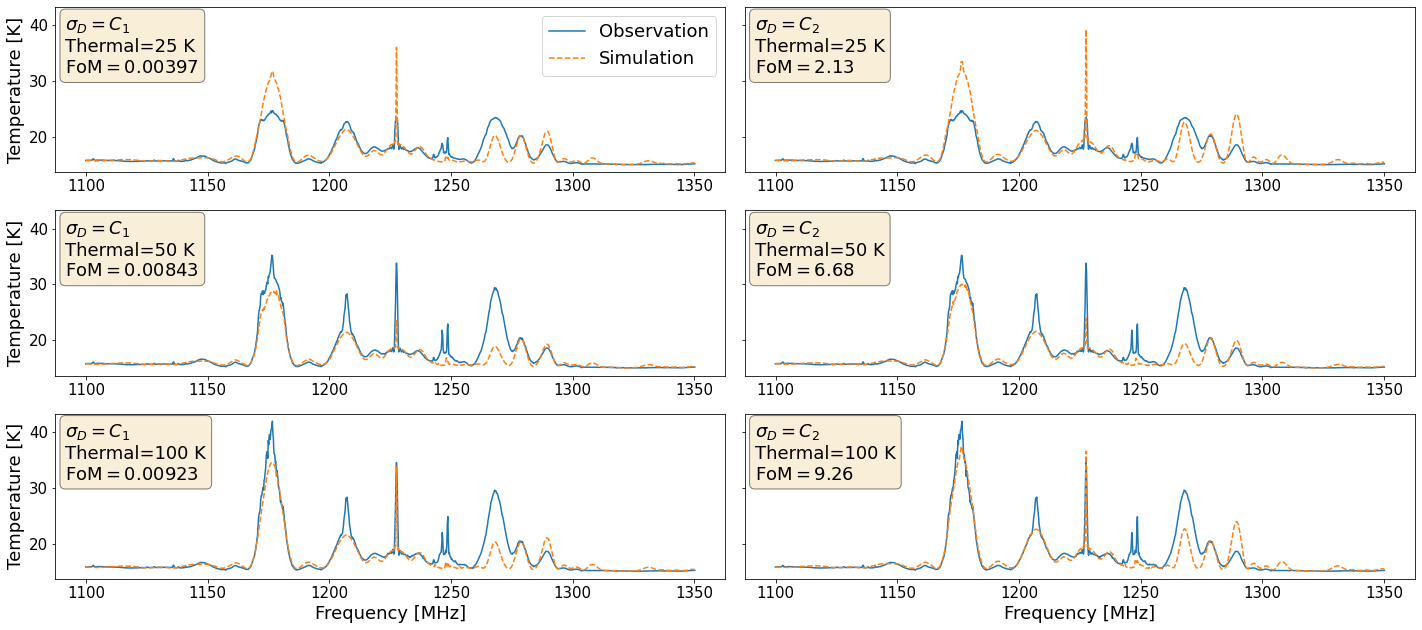

In [12]:
fig, axs = plt.subplots(figsize=(20, 9), nrows=3, ncols=2, sharey=True)

# fig.suptitle(r'Thermal mask:  Comparison fit: Scan period: 1100-1350 MHz')

for ri in range(3):
    ax=axs[ri,0]
    ax.plot(mt_sf[ri][3], np.mean(mt_sf[ri][0], axis=0), label='Observation')
    ax.plot(mt_sf[ri][3], np.mean(mt_sf[ri][1], axis=0), '--', label='Simulation')
    textstr = '\n'.join((
        r'$\sigma_{D}=C_1$',
        r'Thermal='+temperature[ri]+' K',
        r'FoM$=%.5f$' % (np.round(mt_sf[ri][2], 5), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', bbox=props)
    # if ri==0:
    #     # ax.set_title(r'$\chi_{\sigma}=\sigma_{D}$')
    if ri==2:
        ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Temperature [K]')
    if ri==0:
        ax.legend()
    

    
    ax=axs[ri,1]
    ax.plot(mt_sr[ri][3], np.mean(mt_sr[ri][0], axis=0), label='Observation')
    ax.plot(mt_sr[ri][3], np.mean(mt_sr[ri][1], axis=0), '--', label='Simulation')
    textstr = '\n'.join((
        r'$\sigma_{D}=C_2$',
        r'Thermal='+temperature[ri]+' K',
        r'FoM$=%.2f$' % (np.round(mt_sr[ri][2], 2), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', bbox=props)
    
    # if ri==0:
        # ax.set_title(r'$\chi_{\sigma}=1$')
    if ri==2:
        ax.set_xlabel('Frequency [MHz]')
        # ax.legend()
    


fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/thermal2_fitting.pdf')

NameError: name 'f_slice' is not defined

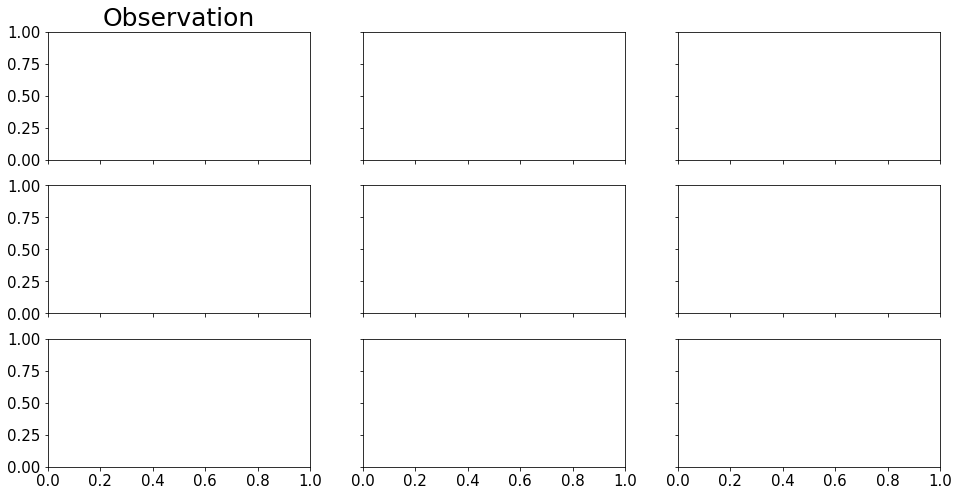

In [13]:
# plots = [mno_sr[0], mno_sf[1], mno_sr[1]]
plots_title = ['Observation', r'$C_1$', r'$C_2$']
fig, axs = plt.subplots(figsize=(16, 8), nrows=3, ncols=3, sharey=True, sharex=True)
for ri in range(3):
    for ci in range(3):
            xi = 3*ri+ci
            ax = axs[ri, ci]
            if ri==0:
                ax.set_title(plots_title[ci])

            if ci==0:
                cax = ax.imshow(mt_sr[ri][0], aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[-1], pm.nd_s0[0]], vmax=np.max(mt_sr[2][0]), vmin=np.min(mt_sr[2][0]))
            elif ci==1:
                cax = ax.imshow(mt_sr[ri][1], aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[-1], pm.nd_s0[0]], vmax=np.max(mt_sr[2][0]), vmin=np.min(mt_sr[2][0]))
            else:
                cax = ax.imshow(mt_sf[ri][1], aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[-1], pm.nd_s0[0]], vmax=np.max(mt_sr[2][0]), vmin=np.min(mt_sr[2][0]))  
            
            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
            
            if ci==0:
                ax.set_ylabel('Time [sec]')
            if ri==2:
                ax.set_xlabel('Frequency [MHz]')

fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/thermal_fitting_waterfall.pdf')

### Temporal avoidance

In [42]:
mtz_loc = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/'+str(pm.file)+'/'+folder+'/time_zones/'

if str(pm.file)==str(1551055211):
    ts = [775, 2200, 5500]
    te = [1000, 2400, 6200]        
if str(pm.file)==str(1562857793):
    ts = [986, 1868, 2338, 4815]
    te = [1850, 2257, 3223, 6689]    
if str(pm.file)==str(1556138397):
    ts = [936, 2183]
    te = [1296, 6634]
if str(pm.file)==str(1556052116):
    ts = [1102, 1724, 5404]
    te = [1225, 4462, 6673]
if str(pm.file)==str(1554156377):
    ts=[938, 2617]
    te=[1365, 6641]
if str(pm.file)==str(1553966342):
    ts=[1005.5]
    te=[4505]
if str(pm.file)==str(1551037708):
    ts=[851, 3543]
    te=[1757, 4623.55]


time_zone = [str(ts[ti])+'-'+str(te[ti]) for ti in range(len(ts))]

file_list = os.listdir(mtz_loc)
file_list.sort()

file_list_s = [] 
for tsi in ts:
    for fl in file_list:
        if str(tsi) in fl:
            file_list_s.append(fl)
            
idx = np.arange(len(file_list_s))
even_idx = idx[::2]
odd_idx = idx[1::2]

mtz_frac = [pickle.load(open(mtz_loc+file_list_s[di],'rb'))
           for di in even_idx]

mtz_resi = [pickle.load(open(mtz_loc+file_list_s[di],'rb'))
           for di in odd_idx]



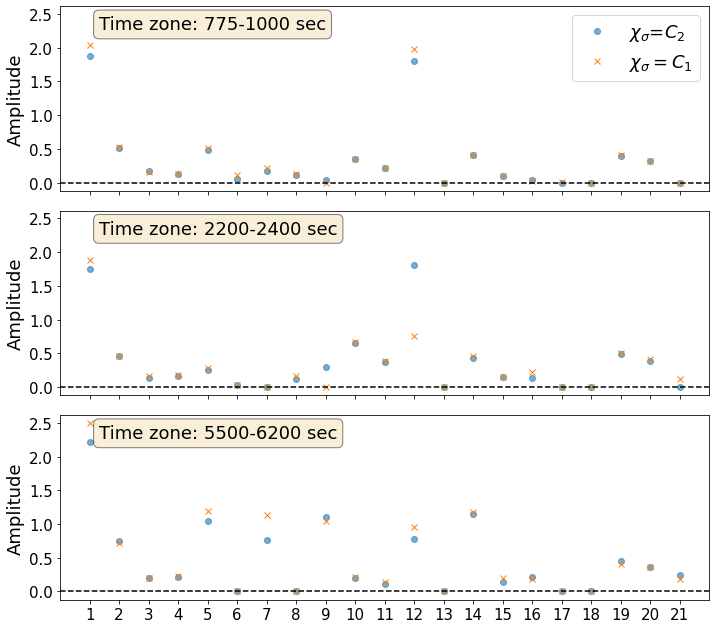

In [43]:
ls = ['o', 'x']
fig, axs = plt.subplots(figsize=(10, len(ts)*3), nrows=len(ts), ncols=1, sharex=True, sharey=True)

# fig.suptitle(r'Temporal mask: $\alpha$ best-fit: Scan period: 1100-1350 MHz')

for ri in range(len(ts)):
    ax=axs[ri]
    # ax.set_title(r'Time period: '+time_zone[ri]+' sec')
    textstr = '\n'.join((
        r'Time zone: '+str(time_zone[ri])+' sec', ),)

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', bbox=props)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xticks(range(1, 21 + 1))
    ax.set_ylabel('Amplitude')
    ax.plot(np.arange(1,22), mtz_frac[ri]['best-fit'], ls[0], alpha=0.6, label=r'$\chi_{\sigma}$=$C_2$')
    ax.plot(np.arange(1,22), mtz_resi[ri]['best-fit'], ls[1], label=r'$\chi_{\sigma}=C_1$')
    ax.axhline(0, linestyle='--', color='k')
    if ri==len(ts):
        ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')
    if ri==0:
        ax.legend(loc='best')

fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/temporal_fitting_alpha.pdf')


In [ ]:
# fig, axs = plt.subplots(figsize=(10, 9), nrows=3, ncols=1)

# fig.suptitle(r'Temporal mask: $\alpha$ best-fit + Dampening: Scan period: 1100-1350 MHz')

# for ri in range(3):
#     ax=axs[ri]
#     ax.set_title(r'Time period: '+time_zone[ri]+' sec')
#     ax.xaxis.set_major_locator(MaxNLocator(integer=True))
#     ax.set_xticks(range(1, 21 + 1))
#     ax.set_ylabel('Best fit value')
#     ax.plot(np.arange(1,22), mtzd_frac[ri]['best-fit'][:21], '-.', label=r'$\chi_{\sigma}$=$\sigma_{D}$')
#     ax.plot(np.arange(1,22), mtzd_resi[ri]['best-fit'][:21], '-.', label=r'$\chi_{\sigma}=1$')
#     if ri==2:
#         ax.set_xlabel(r'$\alpha$ #')
#     ax.legend()

# fig.tight_layout()

#### Checking to see if all constellations have an active $\alpha$

In [ ]:
satellite_catalogue = '/users/bengelbrecht/PhD_Work/Satellite_Code/satellite_RFI-untangle/Notebooks/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2_bw.csv'
sat_data = pd.read_csv(satellite_catalogue, header=0, engine='python')

In [ ]:
sat_data.drop((sat_data[sat_data['Frequency[MHz]'] > 1350].index), inplace=True)
sat_data.drop((sat_data[sat_data['Frequency[MHz]'] < 1100].index), inplace=True)
sat_data.drop((sat_data[sat_data['Sys']=='QZS-1'].index), inplace=True)
sat_data_adjusted = sat_data


In [ ]:
cons_name = np.array(sat_data_adjusted['Sys'])
cons_value = np.round(mtz_frac[0]['best-fit'], 3)


In [ ]:
cons_name = np.array(sat_data_adjusted['Sys'])

fig, axs = plt.subplots(figsize=(10, 3*len(ts)), nrows=len(ts), ncols=1, sharex=True, sharey=True)

fig.suptitle(r'Temporal mask, active constellations')

for ri in range(len(ts)):
    cons_value = np.round(mtz_frac[ri]['best-fit'], 3)
    ax=axs[ri]
    # ax.set_title(r'Time period: '+time_zone[ri]+' sec')
    textstr = '\n'.join((
        r'Time zone: '+str(time_zone[ri])+' sec', ),)

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)
    
    ax.plot(cons_name, cons_value, '.')
    ax.axhline(0, ls='--', color='r', alpha=0.4)
    
    ax.set_ylabel(r'$\alpha$ amplitude')

    if ri==len(ts):
        ax.set_xlabel('Constellation')

fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/temporal_fitting_alpha.pdf')


In [ ]:
ls = ['o', 'x']
fig, axs = plt.subplots(figsize=(10, 3*len(ts)), nrows=len(ts), ncols=1, sharex=True, sharey=True)

# fig.suptitle(r'Temporal mask: $\alpha$ best-fit: Scan period: 1100-1350 MHz')

for ri in range(len(ts)):
    ax=axs[ri]
    # ax.set_title(r'Time period: '+time_zone[ri]+' sec')
    textstr = '\n'.join((
        r'Time zone: '+str(time_zone[ri])+' sec', ),)

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    xticklabels = [str(ci)+':'+cn for ci, cn in enumerate(cons_name)]
    ax.set_xticks(range(0, 20 + 1))
    ax.set_xticklabels(xticklabels, rotation='vertical', fontsize=18)
    ax.set_ylabel(r'$\alpha$ amplitude')
    ax.plot(xticklabels, mtz_frac[ri]['best-fit'], ls[0], alpha=0.6, label=r'$\chi_{\sigma}$=$C_2$')
    ax.axhline(0, ls='--', color='r', alpha=0.2)

    if ri==len(ts):
        ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')

    # ax.legend()

fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/temporal_fitting_alpha.pdf')


#### Temporal avoidance simulation

In [44]:
mtz_sf = [chisq_func2(a_param=mtz_frac[tz]['best-fit'], s_param=None, damper=None, frequency_slice=[1100, 1350], time_slice=[ts[tz], te[tz]], 
                     t_mask=False, d_mask=False ,time_avg=False, chi_sigma=True, verbose=False) for tz,time in enumerate(time_zone)]
  
mtz_sr = [chisq_func2(a_param=mtz_resi[tz]['best-fit'], s_param=None, damper=None, frequency_slice=[1100, 1350], time_slice=[ts[tz], te[tz]], 
                     t_mask=False, d_mask=False ,time_avg=False, chi_sigma=False, verbose=False) for tz,time in enumerate(time_zone)]

f_slice = mtz_sr[0][3]

No masking applied
No masking applied
No masking applied
No masking applied
No masking applied
No masking applied


In [ ]:
# mtzd_sf = [chisq_func2(a_param=mtzd_frac[tz]['best-fit'][:21], s_param=mtzd_frac[tz]['best-fit'][21:], damper='goob', frequency_slice=[1100, 1350], time_slice=[ts[tz], te[tz]],
#                      t_mask=False, d_mask=False ,time_avg=False, chi_sigma=True, verbose=False) for tz,time in enumerate(time_zone)]
  
# mtzd_sr = [chisq_func2(a_param=mtzd_resi[tz]['best-fit'][:21], s_param=mtzd_frac[tz]['best-fit'][21:], damper='goob', frequency_slice=[1100, 1350], time_slice=[ts[tz], te[tz]],
#                      t_mask=False, d_mask=False ,time_avg=False, chi_sigma=False, verbose=False) for tz,time in enumerate(time_zone)]

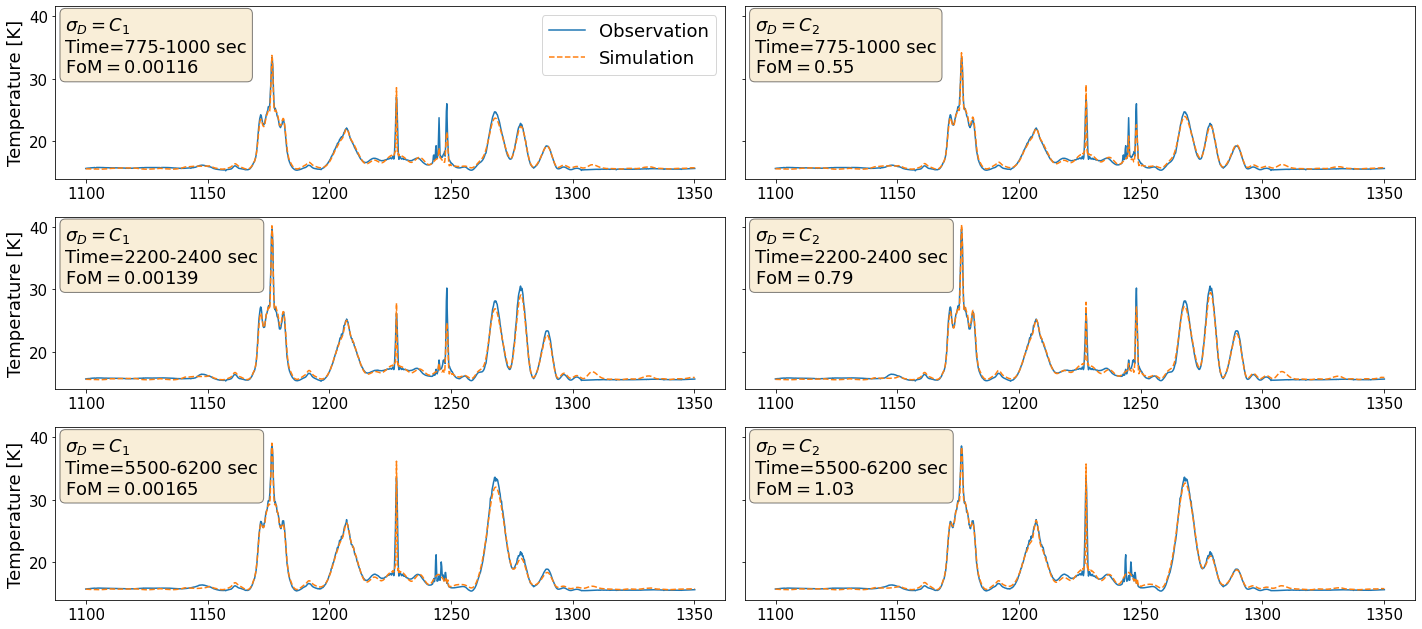

In [45]:
fig, axs = plt.subplots(figsize=(20, 3*len(ts)), nrows=len(ts), ncols=2, sharey=True)

# fig.suptitle(r'Temporal mask: Comparison fit: Scan period: 1100-1350 MHz')

for ri in range(len(ts)):
    ax=axs[ri,0]
    ax.plot(mtz_sf[ri][3], np.ma.mean(mtz_sf[ri][0], axis=0), label='Observation')
    ax.plot(mtz_sf[ri][3], np.ma.mean(mtz_sf[ri][1], axis=0), '--', label='Simulation')
    textstr = '\n'.join((
        r'$\sigma_D=C_1$',
        r'Time='+time_zone[ri]+' sec',
        r'FoM$=%.5f$' % (np.round(mtz_sf[ri][2], 5), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', bbox=props)

    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=\sigma_{D}$')
    if ri==len(ts):
        ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Temperature [K]')
    if ri==0:
        ax.legend()
    

    
    ax=axs[ri,1]
    ax.plot(mtz_sr[ri][3], np.ma.mean(mtz_sr[ri][0], axis=0), label='Observation')
    ax.plot(mtz_sr[ri][3], np.ma.mean(mtz_sr[ri][1], axis=0), '--', label='Simulation')
    textstr = '\n'.join((
        r'$\sigma_D=C_2$',
        r'Time='+time_zone[ri]+' sec',
        r'FoM$=%.2f$' % (np.round(mtz_sr[ri][2], 2), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', bbox=props)
    
    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=1$')
    if ri==len(ts):
        ax.set_xlabel('Frequency [MHz]')
    
    # ax.legend()
    


fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/temporal_fitting.pdf')

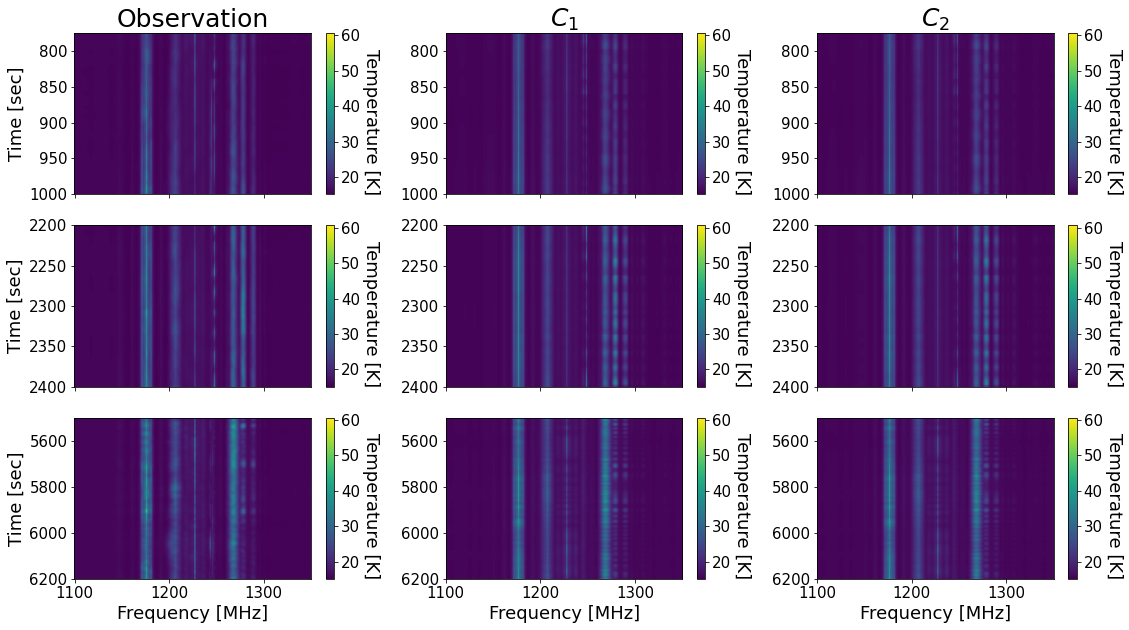

In [46]:
# plots = [mno_sr[0], mno_sf[1], mno_sr[1]]
plots_title = ['Observation', r'$C_1$', r'$C_2$']
fig, axs = plt.subplots(figsize=(16, 3*len(ts)), nrows=len(ts), ncols=3, sharey=False, sharex=True)
for ri in range(len(ts)):
    for ci in range(3):
            xi = 3*ri+ci
            ax = axs[ri, ci]
            if ri==0:
                ax.set_title(plots_title[ci])

            if ci==0:
                cax = ax.imshow(mtz_sr[ri][0], aspect='auto', extent=[f_slice[0], f_slice[-1], te[ri], ts[ri]], vmax=np.max(mtz_sr[1][0]), vmin=np.min(mtz_sr[1][0]))
            elif ci==1:
                cax = ax.imshow(mtz_sr[ri][1], aspect='auto', extent=[f_slice[0], f_slice[-1], te[ri], ts[ri]], vmax=np.max(mtz_sr[1][0]), vmin=np.min(mtz_sr[1][0]))
            else:
                cax = ax.imshow(mtz_sf[ri][1], aspect='auto', extent=[f_slice[0], f_slice[-1], te[ri], ts[ri]], vmax=np.max(mtz_sr[1][0]), vmin=np.min(mtz_sr[1][0]))  
            
            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
            
            if ci==0:
                ax.set_ylabel('Time [sec]')
            if ri==2:
                ax.set_xlabel('Frequency [MHz]')

fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/temporal_fitting_waterfall.pdf')

In [ ]:
fig, axs = plt.subplots(figsize=(16, 3*len(ts)), nrows=len(ts), ncols=2, sharey=True)

# fig.suptitle(r'Temporal mask: Comparison fit: Scan period: 1100-1350 MHz')

for ri in range(len(ts)):
    ax=axs[ri,0]
    ax.plot(mtz_sf[ri][3], np.ma.mean(mtz_sf[ri][0]-mtz_sf[ri][1], axis=0))
    textstr = '\n'.join((
        r'$\sigma_D=C_1$',
        r'Time='+time_zone[ri]+' sec',
        r'FoM$=%.5f$' % (np.round(mtz_sf[ri][2], 5), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', bbox=props)

    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=\sigma_{D}$')
    if ri==2:
        ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Temperature [K]')
    # ax.legend()
    

    
    ax=axs[ri,1]
    ax.plot(mtz_sr[ri][3], np.ma.mean(mtz_sr[ri][0]-mtz_sr[ri][1], axis=0))
    textstr = '\n'.join((
        r'$\sigma_D=C_2$',
        r'Time='+time_zone[ri]+' sec',
        r'FoM$=%.2f$' % (np.round(mtz_sr[ri][2], 2), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', bbox=props)
    
    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=1$')
    if ri==2:
        ax.set_xlabel('Frequency [MHz]')
    
    # ax.legend()
    


fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/temporal_fitting_residaul_2.pdf', bbox_inches='tight')

In [ ]:
# plots = [mno_sr[0], mno_sf[1], mno_sr[1]]
plots_title = [r'$C_1$', r'$C_2$']
fig, axs = plt.subplots(figsize=(16, 3*len(ts)), nrows=len(ts), ncols=2, sharey=False, sharex=True)
for ri in range(len(ts)):
    for ci in range(2):
            xi = 3*ri+ci
            ax = axs[ri, ci]
            if ri==0:
                ax.set_title(plots_title[ci])

            if ci==0:
                cax = ax.imshow(mtz_sr[ri][0] - mtz_sr[ri][1], aspect='auto', extent=[f_slice[0], f_slice[-1], te[ri], ts[ri]], 
                                vmax=20,  vmin=-20)
            else:
                cax = ax.imshow(mtz_sr[ri][0] - mtz_sf[ri][1], aspect='auto', extent=[f_slice[0], f_slice[-1], te[ri], ts[ri]], 
                                vmax=20,  vmin=-20)  
            
            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
            
            if ci==0:
                ax.set_ylabel('Time [sec]')
            if ri==len(ts):
                ax.set_xlabel('Frequency [MHz]')

fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/temporal_fitting_waterfall_residual.pdf')

#### Temporal Residuals

In [ ]:
fig, axs = plt.subplots(figsize=(10, 3*len(ts)), nrows=len(ts), ncols=1, sharey=False)

# fig.suptitle(r'Temporal mask: Comparison fit: Scan period: 1100-1350 MHz')

for ri in range(len(ts)):
    ax=axs[ri]
    ax.plot(mtz_sf[ri][3], np.ma.mean(mtz_sf[ri][0] / mtz_sf[ri][1], axis=0), label='Observation / Simulation')
    textstr = '\n'.join((
        r'$\sigma_D=C_1$',
        r'Time='+time_zone[ri]+' sec',
        r'$\chi^2/N=%.2f$' % (np.round(mtz_sf[ri][2], 2), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)

    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=\sigma_{D}$')
    if ri==2:
        ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Fractional Residual')
    ax.legend()
    
    ax.set_xlim(1220, 1250)
    


fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/temporal_fitting_residual.pdf')

In [ ]:
fslice = mtz_sr[0][3]

In [ ]:
f_val = 1278.75
# f_val = 1202.1

f_id = np.ma.where(fslice>f_val)[0][0]
print (f_id)
size = 1
f_sub = fslice[f_id-size:f_id+size]
print (f_sub)


In [ ]:
def frequency_finder(frequency, f_value, size):
    '''
    frequency - frequency range we ae using
    f_value - frequency value within range that we are interested in
    size - bandwidth
    '''
    f_id = np.ma.where(frequency>f_value)[0][0]
    f_sub = frequency[f_id-size:f_id+size]
    print (f_sub)
    return [f_id-size,f_id+size]

In [ ]:
gal_e6_f = frequency_finder(frequency=fslice, f_value=1278.75, size=1)
glo_l2sf_f = frequency_finder(frequency=fslice, f_value=1245.10, size=1)

In [ ]:
time_idx = [[0,86],[548,625],[1820,2095]]

In [ ]:
cosmos_2477_t = sats_5deg['angle_sep'][0]
gsat_0209_t = sats_5deg['angle_sep'][1]


In [ ]:
# md_sr_resi = md_sr[3][0] / md_sr[3][1]

# md_sr_resi2 = np.ma.mean(md_sr_resi[:, f_id-size:f_id+size], axis=1)

# avgResult_x = np.average(sats_ang.reshape(-1, n), axis=1)
# avgResult = np.ma.array([np.ma.average(md_sr_resi[:-3][0+n*i:n+n*i], axis=0) for i in range(int(2200/n))])

In [ ]:
mtz_sr_resi = [mtz_sr[i][0] / mtz_sr[i][1] for i in range(3)]
mtz_sf_resi = [mtz_sf[i][0] / mtz_sf[i][1] for i in range(3)]

# Residual for the temporal maps
mtz_sr_resi_time_gal = [np.ma.mean(mtz_sr_resi[i][:, gal_e6_f[0]:gal_e6_f[1]], axis=1) for i in range(3)]
mtz_sf_resi_time_gal = [np.ma.mean(mtz_sf_resi[i][:, gal_e6_f[0]:gal_e6_f[1]], axis=1) for i in range(3)]

mtz_sr_resi_time_glo = [np.ma.mean(mtz_sr_resi[i][:, glo_l2sf_f[0]:glo_l2sf_f[1]], axis=1) for i in range(3)]
mtz_sf_resi_time_glo = [np.ma.mean(mtz_sf_resi[i][:, glo_l2sf_f[0]:glo_l2sf_f[1]], axis=1) for i in range(3)]

In [ ]:
fig, axs = plt.subplots(figsize=(12, 12), nrows=3, ncols=1)
for i in range(3):

    ax=axs[i]
    ax.plot(gsat_0209_t[time_idx[i][0]:time_idx[i][1]], mtz_sf_resi_time_gal[i], '.', label='Observation/Simulation')
    # if i==0:
    #     ax.hlines(1, 19, 27, ls='--')
    # elif i==1:
    #     ax.hlines(1, 8, 17, ls='--')
    # else:
    #     ax.hlines(1, 14, 19, ls='--')
        
    textstr = '\n'.join((
        r'$\sigma_D=C_1$',
        r'Time='+time_zone[i]+' sec',
        r'$\nu$=1278.6-1278.8 MHz',))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.2)
    # place a text box in upper left in axes coords
    ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)

    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=\sigma_{D}$')
    if i==2:
        ax.set_xlabel('Angular Seperation [Deg]')
    ax.set_ylabel('Fractional Residual')
    ax.legend(loc='lower right')
    
fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/temporal_fitting_residual_ang.pdf')

In [ ]:
fig, axs = plt.subplots(figsize=(12, 12), nrows=3, ncols=1)
for i in range(3):

    ax=axs[i]
    ax.plot(cosmos_2477_t[time_idx[i][0]:time_idx[i][1]], mtz_sf_resi_time_glo[i], '.', label='Obs/Sim')
    
    textstr = '\n'.join((
        r'$\sigma_D=C_1$',
        r'Time='+time_zone[i]+' sec',))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.2)
    # place a text box in upper left in axes coords
    ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)

    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=\sigma_{D}$')
    if i==2:
        ax.set_xlabel('Angular Seperation')
    ax.set_ylabel('Fractional Residual')
    ax.legend(loc='lower right')

#### Temporal plot with coarse grain

In [ ]:
mtz_loc = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/'+str(pm.file)+'/'+folder+'/time_average/'

# # 1551055211
# ts = [775, 2200, 5500]
# te = [1000, 2400, 6200]

# # 1562857793
# ts = [986, 1868, 2338, 4815]
# te = [1850, 2257, 3223, 6689]

# # 1556138397
# ts = [936, 2183]
# te = [1296, 6634]

# 1556052116 
ts = [1102, 1724, 5404]
te = [1225, 4462, 6673]

# 1556138397

time_zone = [str(ts[ti])+'-'+str(te[ti]) for ti in range(len(ts))]

file_list = os.listdir(mtz_loc)
file_list.sort()

file_list_s = [] 
for tsi in ts:
    for fl in file_list:
        if str(tsi) in fl:
            file_list_s.append(fl)
            
idx = np.arange(len(file_list_s))
even_idx = idx[::2]
odd_idx = idx[1::2]

mtza_frac = [pickle.load(open(mtz_loc+file_list_s[di],'rb'))
           for di in even_idx]

mtza_resi = [pickle.load(open(mtz_loc+file_list_s[di],'rb'))
           for di in odd_idx]



In [ ]:
mtza_sf = [chisq_func2(a_param=mtza_frac[tz]['best-fit'], s_param=None, damper=None, frequency_slice=[1100, 1350], time_slice=[ts[tz], te[tz]], 
                     t_mask=False, d_mask=False ,time_avg=10, chi_sigma=True, verbose=False) for tz,time in enumerate(time_zone)]
  


In [ ]:
# plots = [mno_sr[0], mno_sf[1], mno_sr[1]]
plots_title = ['Observation', r'$C_1$']
fig, axs = plt.subplots(figsize=(16, 3*len(ts)), nrows=len(ts), ncols=2, sharex=True)
for ri in range(len(ts)):
    for ci in range(2):
            xi = 3*ri+ci
            ax = axs[ri, ci]
            if ri==0:
                ax.set_title(plots_title[ci])

            if ci==0:
                cax = ax.imshow(mtza_sf[ri][0], aspect='auto', extent=[f_slice[0], f_slice[-1], te[ri], ts[ri]], vmax=np.max(mtz_sr[1][0]), vmin=np.min(mtz_sr[1][0]))
            elif ci==1:
                cax = ax.imshow(mtza_sf[ri][1], aspect='auto', extent=[f_slice[0], f_slice[-1], te[ri], ts[ri]], vmax=np.max(mtz_sr[1][0]), vmin=np.min(mtz_sr[1][0]))  
            
            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
            
            if ci==0:
                ax.set_ylabel('Time [sec]')
            if ri==2:
                ax.set_xlabel('Frequency [MHz]')

fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/temporal2_fitting_waterfall.pdf')

In [ ]:
fig, axs = plt.subplots(figsize=(20, 4*len(ts)), nrows=len(ts), ncols=1, sharey=True)

# fig.suptitle(r'Temporal mask: Comparison fit: Scan period: 1100-1350 MHz')

for ri in range(len(ts)):
    ax=axs[ri]
    ax.plot(mtza_sf[ri][3], np.ma.mean(mtza_sf[ri][0], axis=0), label='Observation')
    ax.plot(mtza_sf[ri][3], np.ma.mean(mtza_sf[ri][1], axis=0), '--', label='Simulation')
    textstr = '\n'.join((
        r'$\sigma_D=C_1$',
        r'Time='+time_zone[ri]+' sec',
        r'$\chi^2/N=%.5f$' % (np.round(mtza_sf[ri][2]/dem, 5), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', bbox=props)

    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=\sigma_{D}$')
    if ri==len(ts):
        ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Temperature [K]')
    ax.legend()
    


# fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/temporal2_fitting.pdf')

In [ ]:
fig, axs = plt.subplots(figsize=(14, 3*len(ts)), nrows=len(ts), ncols=1, sharey=True)

# fig.suptitle(r'Temporal mask: Comparison fit: Scan period: 1100-1350 MHz')

for ri in range(len(ts)):
    ax=axs[ri]
    ax.plot(mtz_sf[ri][3], np.ma.mean(mtz_sf[ri][0]-mtz_sf[ri][1], axis=0), label='Residual')
    ax.plot(mtza_sf[ri][3], np.ma.mean(mtza_sf[ri][0]-mtza_sf[ri][1], axis=0), alpha=0.5, label='Residual Average')

    textstr = '\n'.join((
        r'$\sigma_D=C_1$',
        r'Time='+time_zone[ri]+' sec',))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', bbox=props)

    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=\sigma_{D}$')
    if ri==len(ts):
        ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Temperature [K]')
    ax.legend()
    


# fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/temporal2_fitting.pdf')

In [ ]:
# mtza_sf_resi = [mtza_sf[i][0] / mtza_sf[i][1] for i in range(len(ts))]

# # Residual for the temporal maps
# mtza_sf_resi_time_gal = [np.ma.mean(mtza_sf_resi[i][:, gal_e6_f[0]:gal_e6_f[1]], axis=1) for i in range(3)]

# mtza_sf_resi_time_glo = [np.ma.mean(mtza_sf_resi[i][:, glo_l2sf_f[0]:glo_l2sf_f[1]], axis=1) for i in range(3)]


In [ ]:
ls = ['o', 'x']
fig, axs = plt.subplots(figsize=(10, 3*len(ts)), nrows=len(ts), ncols=1, sharex=True, sharey=True)

# fig.suptitle(r'Temporal mask: $\alpha$ best-fit: Scan period: 1100-1350 MHz')

for ri in range(len(ts)):
    ax=axs[ri]
    # ax.set_title(r'Time period: '+time_zone[ri]+' sec')
    textstr = '\n'.join((
        r'Time zone: '+str(time_zone[ri])+' sec', ),)

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xticks(range(1, 21 + 1))
    ax.set_ylabel('Amplitude')
    ax.plot(np.arange(1,22), mtza_frac[ri]['best-fit'], ls[0], alpha=0.6, label=r'10 second average')
    ax.plot(np.arange(1,22), mtz_frac[ri]['best-fit'], ls[1], alpha=1, label=r'No averaging')
    if ri==len(ts):
        ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')
    if ri==0:
        ax.legend()

fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/temporal_fitting_alpha_avg2.pdf')


In [ ]:
gsat_0209_t10 = [tools.waterfall_avg_time(timer=pm.nd_s0[mtza_sf[i][4][0]:mtza_sf[i][4][1]], size=10, waterfall=gsat_0209_t[mtza_sf[i][4][0]:mtza_sf[i][4][1]]) for i in range(3)]

In [ ]:
gsat_0209_t10[2].shape

In [ ]:
fig, axs = plt.subplots(figsize=(9, 12), nrows=3, ncols=1)

ax=axs[0]
ax.plot(gsat_0209_t10[0][:-1], mtza_sf_resi_time_gal[0][:-1], '.', label='Observation/Simulation')
# ax.hlines(1, 19, 27, ls='--')
ax.set_ylabel('Fractional Residual')
ax.legend(loc='lower right')
textstr = '\n'.join((
    r'$\sigma_D=C_1$',
    r'Time='+time_zone[0]+' sec',
    r'$\nu$=1278.6-1278.8 MHz',))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.2)
# place a text box in upper left in axes coords
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

ax=axs[1]
ax.plot(gsat_0209_t10[1][:-1], mtza_sf_resi_time_gal[1][:-1], '.', label='Observation/Simulation')
# ax.hlines(1, 14, 19, ls='--')
ax.set_ylabel('Fractional Residual')
ax.legend(loc='lower right')
textstr = '\n'.join((
    r'$\sigma_D=C_1$',
    r'Time='+time_zone[1]+' sec',
    r'$\nu$=1278.6-1278.8 MHz',))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.2)
# place a text box in upper left in axes coords
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

ax=axs[2]
ax.plot(gsat_0209_t10[2][:-1], mtza_sf_resi_time_gal[2][:-1], '.', label='Observation/Simulation')
# ax.hlines(1, 8, 17, ls='--')

textstr = '\n'.join((
    r'$\sigma_D=C_1$',
    r'Time='+time_zone[2]+' sec',
    r'$\nu$=1278.6-1278.8 MHz',))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.2)
# place a text box in upper left in axes coords
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

# if ri==0:
#     ax.set_title(r'$\chi_{\sigma}=\sigma_{D}$')

ax.set_xlabel('Angular Seperation [Deg]')
ax.set_ylabel('Fractional Residual')
ax.legend(loc='lower right')
    
fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/temporal_fitting_residual_ang2.pdf')

In [ ]:
time_10avg = [gsat_0209_t10[0][:-1], gsat_0209_t10[1][:], gsat_0209_t10[2][:-1]]
mtza_sf_resi_time_gal = [mtza_sf_resi_time_gal[0][:-1], mtza_sf_resi_time_gal[1][:-1], mtza_sf_resi_time_gal[2][:-1]]


In [ ]:
fig, axs = plt.subplots(figsize=(24, 12), nrows=3, ncols=2, sharey='row')


for ri1 in range(3):
    ax=axs[ri1, 0]
    ax.plot(gsat_0209_t[time_idx[ri1][0]:time_idx[ri1][1]], mtz_sf_resi_time_gal[ri1], '.', label='No averaging')
    if ri1==2:
        ax.set_xlabel('Angular Seperation [Deg]', fontsize=25)
    ax.set_ylabel('Fractional Residual', fontsize=25)
    if ri1==0:
        ax.legend(loc='lower right', fontsize=20)

    textstr = '\n'.join((
        r'$\sigma_D=C_1$',
        r'Time='+time_zone[i]+' sec',
        r'$\nu$=1278.6-1278.8 MHz',))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.2)
    # place a text box in upper left in axes coords
    ax.text(0.01, 0.95, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', bbox=props)
    
    ax.yaxis.set_tick_params(labelsize=20)
    ax.xaxis.set_tick_params(labelsize=20)

        

for ri2 in range(3):
    ax=axs[ri2, 1]
    if ri2==0:
        ax.plot(time_10avg[ri2], mtza_sf_resi_time_gal[ri2], '.', label='Ten second averaging')
    elif ri2==1:
        ax.plot(time_10avg[ri2][:-1], mtza_sf_resi_time_gal[ri2], '.')
    else:
        ax.plot(time_10avg[ri2], mtza_sf_resi_time_gal[ri2], '.')
        
    if ri2==2:
        ax.set_xlabel('Angular Seperation [Deg]', fontsize=25)
    if ri2==0:
        ax.legend(loc='lower right', fontsize=20)
        
    ax.xaxis.set_tick_params(labelsize=20)
    
        
fig.tight_layout()
fig.savefig('/users/bengelbrecht/Plots/temporal_fitting_residual_ang3.pdf', bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(figsize=(9, 12), nrows=3, ncols=1)
for i in range(3):

    ax=axs[i]
    if i==0:
        ax.plot(time_10avg[i], mtza_sf_resi_time_gal[i], '.', label='Observation/Simulation')
    elif i==1:
        ax.plot(time_10avg[i][:-1], mtza_sf_resi_time_gal[i], '.', label='Observation/Simulation')
    else:
        ax.plot(time_10avg[i], mtza_sf_resi_time_gal[i], '.', label='Observation/Simulation')

    
    textstr = '\n'.join((
        r'$\sigma_D=C_1$',
        r'Time='+time_zone[i]+' sec',
        r'$\nu$=1278.6-1278.8 MHz',))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.2)
    # place a text box in upper left in axes coords
    ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)

    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=\sigma_{D}$')
    if i==2:
        ax.set_xlabel('Angular Seperation [Deg]')
    ax.set_ylabel('Fractional Residual')

    
fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/temporal_fitting_residual_ang.pdf')

#### Temporal mask + fitting above 17 kelvin

In [ ]:
mtz_loc = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/sat_8/time_zones_average/'

time_zone = ['775-1000', '2200-2400', '5500-6200']
ts = [775, 2200, 5500]
te = [1000, 2400, 6200]

# No dampening - averaged - radiometer - fit above 17 kelvin
mtza_frac_sfit = [pickle.load(open(mtz_loc+'1551055211_1100-1350_'+str(tzi)+'_no-mask_no-dampening_fraction_time_average_10_v1.p','rb'))
           for tzi in time_zone]



In [ ]:
mtza_sf_fit = [chisq_func2(a_param=mtza_frac_sfit[tz]['best-fit'], s_param=None, damper=None, frequency_slice=[1100, 1350], time_slice=[ts[tz], te[tz]], 
                     t_mask=False, d_mask=False ,time_avg=10, chi_sigma=True, verbose=False) for tz,time in enumerate(time_zone)]
  


In [ ]:
# plots = [mno_sr[0], mno_sf[1], mno_sr[1]]
plots_title = ['Observation', r'$C_1$']
fig, axs = plt.subplots(figsize=(10, 6), nrows=3, ncols=2, sharey=False)
for ri in range(3):
    for ci in range(2):
            xi = 3*ri+ci
            ax = axs[ri, ci]
            if ri==0:
                ax.set_title(plots_title[ci])
                rext_s, rext_e=0, 86
            elif ri==1:
                rext_s, rext_e=548, 624
            else:
                rext_s, rext_e=1820, 2094

            if ci==0:
                cax = ax.imshow(mtza_sf_fit[ri][0], aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[rext_e], pm.nd_s0[rext_s]], vmax=np.max(mtz_sr[1][0]), vmin=np.min(mtz_sr[1][0]))
            elif ci==1:
                cax = ax.imshow(mtza_sf_fit[ri][1], aspect='auto', extent=[f_slice[0], f_slice[-1], pm.nd_s0[rext_e], pm.nd_s0[rext_s]], vmax=np.max(mtz_sr[1][0]), vmin=np.min(mtz_sr[1][0]))  
            
            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
            
            if ci==0:
                ax.set_ylabel('Time [sec]')
            if ri==2:
                ax.set_xlabel('Frequency [MHz]')

fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/temporal2_fitting_waterfall.pdf')

In [ ]:
fig, axs = plt.subplots(figsize=(20, 9), nrows=3, ncols=1, sharey=True)

# fig.suptitle(r'Temporal mask: Comparison fit: Scan period: 1100-1350 MHz')

for ri in range(3):
    ax=axs[ri]
    ax.plot(mtza_sf_fit[ri][3], np.ma.mean(mtza_sf_fit[ri][0], axis=0), label='Observation')
    ax.plot(mtza_sf_fit[ri][3], np.ma.mean(mtza_sf_fit[ri][1], axis=0), '--', label='Simulation')
    textstr = '\n'.join((
        r'$\sigma_D=C_1$',
        r'Time='+time_zone[ri]+' sec',
        r'$\chi^2/N=%.2f$' % (np.round(mtza_sf_fit[ri][2], 2), ),))

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)

    # if ri==0:
    #     ax.set_title(r'$\chi_{\sigma}=\sigma_{D}$')
    if ri==2:
        ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Temperature [K]')
    ax.legend()
    


fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/temporal2_fitting.pdf')

In [ ]:
ls = ['o', 'x', '*']
fig, axs = plt.subplots(figsize=(10, 9), nrows=3, ncols=1, sharex=True, sharey=False)

# fig.suptitle(r'Temporal mask: $\alpha$ best-fit: Scan period: 1100-1350 MHz')

for ri in range(3):
    ax=axs[ri]
    # ax.set_title(r'Time period: '+time_zone[ri]+' sec')
    textstr = '\n'.join((
        r'Time zone: '+str(time_zone[ri])+' sec', ),)

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # place a text box in upper left in axes coords
    ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xticks(range(1, 21 + 1))
    ax.set_ylabel('Amplitude')
    ax.plot(np.arange(1,22), mtza_frac[ri]['best-fit'], ls[0], alpha=0.6, label=r'10 second average')
    ax.plot(np.arange(1,22), mtz_frac[ri]['best-fit'], ls[1], alpha=1, label=r'No averaging')
    ax.plot(np.arange(1,22), mtza_frac_sfit[ri]['best-fit'], ls[2], alpha=0.6, label=r'10 second average + 17 k')

    if ri==2:
        ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')

    ax.legend()

fig.tight_layout()
# fig.savefig('/users/bengelbrecht/Plots/temporal_fitting_alpha_avg2.pdf')


### Running for the extended frequency range

Code for running the data without the background model

Note that the 2d angular satellite maps should be in the correct frequency range.

Note that the frequency range should be further than the length set

Once you set the number of satellites you cannot increase or decrease the satellite information. Have to keep the same length of satellites

In [47]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
##CHI SQAURE METHOD
def chisq_func3(a_param, s_param=None, damper=None, satellites_only=True, sat_info=pm.satellite_catalogue, add_sub=[False, True],
                frequency_slice=False, time_slice=False, t_mask=False, d_mask=False ,time_avg=False, verbose=False):
    
    if d_mask==False:
        satellites=None
    else:
        satellites=pm.data_save+'nearby_satellites/nearby_satellite_close_angle_'+d_mask+'.p'
    
    """INITIALIZING THE SATELLITE FUNCTION"""
    sat = ss(file_name=str(pm.file), 
                 sats_only=satellites_only, 
                 data_loc=pm.data_save, 
                 sat_loc=pm.data_save,
                 survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency], 
                 sat_info=sat_info,
                 plots_loc=pm.data_plot,
                 sat_beam=pm.beam_model+'_beam_'+str(950)+'_'+str(1500)+'MHz', 
                 frequency_range=[950, 1500], 
                 constellations=pm.constellations_remain,
                 nearby_satellites=satellites,
                 verbose=False)
    
    """EXCECUTING THE THE SATELLITE SIM FUNCTION"""
    sat.excecute(a_param=a_param, 
                 obs_time_start=time_slice[0], obs_time_end=time_slice[1], 
                 obs_frequency_start=frequency_slice[0], obs_frequency_end=frequency_slice[1], 
                 file_bias_choice=pm.bias, 
                 add_sub=[add_sub[0], add_sub[1]], 
                 attenuation_func=damper, 
                 attenuation_sigma=s_param, 
                 bandsize=None,
                 verbose=False)

    """FREQUENCY SLICE"""
    frange_slice = sat.frequency_band[sat.frequency_idx[0]:sat.frequency_idx[1]]  
    if satellites_only==False:
        """MASKING"""
        ## TEMPERATURE MASKING 
        if t_mask!=False and d_mask==False:
            print ('Temperature mask of '+str(t_mask)+' Kelvin')
            zero_arr = np.zeros(sat.calibration_data_slice.shape)
            mask_idx = np.where(sat.calibration_data_slice > t_mask)

            zero_arr[mask_idx]=1
            simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=zero_arr.T)    #SIMULATIONS
            data = np.ma.array(data=sat.calibration_data_slice.T, mask=zero_arr.T)  #DATA

        ## DEGREE MASKING
        elif d_mask!=False and t_mask==False:
            print ("Area mask of "+str(d_mask)+" degrees")
            simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=sat.mask_nearby_satellites_slice)
            data = np.ma.array(data=sat.calibration_data_slice.T, mask=sat.mask_nearby_satellites_slice)

        ## NO MASKING
        else:
            print ("No masking applied")
            simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=None)
            data = np.ma.array(data=sat.calibration_data_slice.T, mask=None)
        return data, simulation, frange_slice#, sat.sat_data_adjusted
    else:
        if d_mask!=False:
            print ('Masking and Satellites Only')
            simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=sat.mask_nearby_satellites_slice)
        else:
            print ("No masking and Satellites Only")
            simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=None)
        return simulation, frange_slice#, sat.sat_data_adjusted        
        


    

In [ ]:
# Temporal Avoidance

In [ ]:
# data, sim, fslice = chisq_func3(a_param=mtz_frac[0]['best-fit'], s_param=None, damper=None, 
#             frequency_slice=[980, 1350], time_slice=[None, None],
#             t_mask=False, d_mask=False,
#             time_avg=False, chi_sigma=True, verbose=True, chiSquare=False)
  

In [49]:
sim_ext, frange_ext = chisq_func3(a_param=mtz_frac[1]['best-fit'], s_param=None, damper=None, frequency_slice=[973, 1350], time_slice=[None, None], 
                     t_mask=False, d_mask='5F' ,time_avg=False, verbose=False)

Masking and Satellites Only


In [50]:
fend_idx = np.where(frange_ext>1015)[0][0]
frange_reduced = frange_ext[:fend_idx]
sim_e_reduced = sim_ext[:, :fend_idx]
# data_f_reduced = data[:, :fend_idx]

# rext_s, rext_e=0, 86
# rext_s, rext_e=548, 624
# rext_s, rext_e=1820, 2094

In [34]:
pm.file

1551055211

In [54]:
antenna_no = 'm000'

resi_hh4 = pickle.load(open('/users/bengelbrecht/Tresid_'+str(pm.file)+'_'+antenna_no+'h_l4masks', 'rb'), encoding='latin1')
resi_vv4 = pickle.load(open('/users/bengelbrecht/Tresid_'+str(pm.file)+'_'+antenna_no+'v_l4masks', 'rb'), encoding='latin1')

In [55]:
fs, fe = tools.find_idx(data_array=pm.frequency, data_variable=973), tools.find_idx(data_array=pm.frequency, data_variable=1015.2)


In [56]:
resi_hh4_2 = resi_hh4[pm.nd_s0_pos, fs:fe][:-1, :]
resi_hh4_2m = np.ma.array(data=resi_hh4_2, mask=sim_e_reduced.mask)

resi_vv4_2 = resi_vv4[pm.nd_s0_pos, fs:fe][:-1, :]
resi_vv4_2m = np.ma.array(data=resi_vv4_2, mask=sim_e_reduced.mask)


sim_em_reduced = np.ma.array(data=sim_e_reduced, mask=resi_hh4_2m.mask)

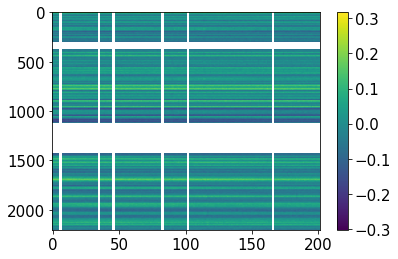

In [57]:
plt.imshow(resi_hh4_2, aspect='auto')
plt.colorbar()

In [ ]:
print (resi_hh4_2m.shape)
print (resi_vv4_2m.shape)
print (sim_em_reduced.shape)

In [ ]:
fig, axs = plt.subplots(figsize=(12,6), nrows=1, ncols=2)
ax=axs[0]
ax.set_title('HH Polarisation')
cax = ax.imshow((resi_hh4[pm.nd_s0_pos, :]), aspect='auto', extent=[pm.frequency[0], pm.frequency[-1], pm.nd_s0[-1], pm.nd_s0[0]]) 
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Time [sec]')

ax=axs[1]
ax.set_title('VV Polarisation')
cax = ax.imshow((resi_vv4[pm.nd_s0_pos, :]), aspect='auto', extent=[pm.frequency[0], pm.frequency[-1], pm.nd_s0[-1], pm.nd_s0[0]])
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Time [sec]')

fig.tight_layout()

In [ ]:
resi_vv4_2m.shape

In [ ]:
fig, axs = plt.subplots(figsize=(12,6), nrows=1, ncols=2)
ax=axs[0]
ax.set_title('HH Polarisation')
# cax = ax.imshow((resi_hh4[pm.nd_s0_pos, fs:fe]), aspect='auto', extent=[pm.frequency[fs], pm.frequency[fe], pm.nd_s0[-1], pm.nd_s0[0]]) 
cax = ax.imshow((resi_hh4_2), aspect='auto', extent=[pm.frequency[fs], pm.frequency[fe], pm.nd_s0[-1], pm.nd_s0[0]])

cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Time [sec]')

ax=axs[1]
ax.set_title('VV Polarisation')
# cax = ax.imshow((resi_vv4[pm.nd_s0_pos, fs:fe]), aspect='auto', extent=[pm.frequency[fs], pm.frequency[fe], pm.nd_s0[-1], pm.nd_s0[0]])
cax = ax.imshow((resi_vv4_2), aspect='auto', extent=[pm.frequency[fs], pm.frequency[fe], pm.nd_s0[-1], pm.nd_s0[0]])


cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Time [sec]')

fig.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=1)

# ax.plot(frange_reduced, np.ma.mean(sim_em_reduced, axis=0), label='Extended satellite signal')
ax.plot(frange_reduced, np.ma.mean((resi_hh4_2), axis=0), label='Tresi l4 HH')
ax.plot(frange_reduced, np.ma.mean((resi_vv4_2), axis=0), label='Tresi l4 VV')

ax.legend()
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [K]')
fig.tight_layout()

#### Mask all values below 0 and plot again


In [ ]:
resi_hh4_2m0 = np.ma.array(data=resi_hh4_2m, mask=resi_hh4_2m.data < 0)
resi_vv4_2m0 = np.ma.array(data=resi_vv4_2m, mask=resi_vv4_2m.data < 0)

In [ ]:
fig, axs = plt.subplots(figsize=(12,6), nrows=1, ncols=2)
ax=axs[0]
ax.set_title('HH Polarisation')
cax = ax.imshow((resi_hh4_2m0), aspect='auto', extent=[pm.frequency[fs], pm.frequency[fe], pm.nd_s0[-1], pm.nd_s0[0]]) 
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Time [sec]')

ax=axs[1]
ax.set_title('VV Polarisation')
cax = ax.imshow((resi_vv4_2m0), aspect='auto', extent=[pm.frequency[fs], pm.frequency[fe], pm.nd_s0[-1], pm.nd_s0[0]])
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Time [sec]')

fig.tight_layout()

In [ ]:
sim_em0_reduced = np.ma.array(data=sim_em_reduced, mask=resi_hh4_2m0.mask)

fig, axs = plt.subplots(figsize=(6,6), nrows=1, ncols=1)
ax=axs
ax.set_title('Model estimate')
cax = ax.imshow((sim_em0_reduced), aspect='auto', extent=[pm.frequency[fs], pm.frequency[fe], pm.nd_s0[-1], pm.nd_s0[0]]) 
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Time [sec]')

fig.tight_layout()

In [ ]:
 fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=1)

ax.plot(frange_reduced, np.ma.mean(sim_em0_reduced, axis=0), label='Extended satellite signal')
ax.plot(frange_reduced, np.ma.mean(np.ma.abs(resi_hh4_2m0), axis=0), label='Tresi l4 HH')
ax.plot(frange_reduced, np.ma.mean(np.ma.abs(resi_vv4_2m0), axis=0), label='Tresi l4 VV')

ax.legend()
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [K]')
fig.tight_layout()

#### Subtracting the frequency average per channel

In [ ]:
plt.imshow(resi_hh4_2m.mask, aspect='auto')

In [ ]:
resi_hh4_2mt = np.zeros((resi_hh4_2.shape))
resi_vv4_2mt = np.zeros((resi_vv4_2.shape))
sim_emt_reduced = np.zeros((sim_em_reduced.shape))

In [ ]:
resi_hh4_2mt = np.ma.array(data=resi_hh4_2mt, mask=resi_hh4_2m.mask)
resi_vv4_2mt = np.ma.array(data=resi_vv4_2mt, mask=resi_vv4_2m.mask)
sim_emt_reduced = np.ma.array(data=sim_emt_reduced, mask=sim_em_reduced.mask)

In [ ]:
for i in range(resi_hh4_2.shape[1]):
    resi_hh4_2mt[:, i] = resi_hh4_2m[:, i] - np.ma.mean(resi_hh4_2m[:, i])
    resi_vv4_2mt[:, i] = resi_vv4_2m[:, i] - np.ma.mean(resi_vv4_2m[:, i])
    sim_emt_reduced[:, i] = sim_em_reduced[:, i] - np.ma.mean(sim_em_reduced[:, i])


In [ ]:
fig, axs = plt.subplots(figsize=(12,6), nrows=1, ncols=2)
ax=axs[0]
ax.set_title('HH Polarisation')
cax = ax.imshow((resi_hh4_2mt), aspect='auto', extent=[pm.frequency[fs], pm.frequency[fe], pm.nd_s0[-1], pm.nd_s0[0]]) 
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Time [sec]')

ax=axs[1]
ax.set_title('VV Polarisation')
cax = ax.imshow((resi_vv4_2mt), aspect='auto', extent=[pm.frequency[fs], pm.frequency[fe], pm.nd_s0[-1], pm.nd_s0[0]])
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Time [sec]')

fig.tight_layout()

In [ ]:
sim_em0_reduced = np.ma.array(data=sim_em_reduced, mask=resi_hh4_2m0.mask)

fig, axs = plt.subplots(figsize=(6,6), nrows=1, ncols=1)
ax=axs
ax.set_title('Model estimate')
cax = ax.imshow((sim_emt_reduced), aspect='auto', extent=[pm.frequency[fs], pm.frequency[fe], pm.nd_s0[-1], pm.nd_s0[0]]) 
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Time [sec]')

fig.tight_layout()

In [ ]:
#  fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=1)

# ax.plot(frange_reduced, np.ma.mean(sim_emt_reduced, axis=), label='Extended satellite signal')
# ax.plot(frange_reduced, np.ma.mean((resi_hh4_2mt), axis=0), label='Tresi l4 HH')
# ax.plot(frange_reduced, np.ma.mean((resi_vv4_2mt), axis=0), label='Tresi l4 VV')

# ax.legend()
# ax.set_xlabel('Frequency [MHz]')
# ax.set_ylabel('Temperature [K]')
# fig.tight_layout()

In [ ]:
# resi_hh4_2mt = np.zeros((resi_hh4_2.shape))
# resi_vv4_2mt = np.zeros((resi_vv4_2.shape))
# sim_emt_reduced = np.zeros((sim_em_reduced.shape))

# for i in range(resi_hh4_2.shape[0]):
#     resi_hh4_2mt[i, :] = resi_hh4_2m[i, :] - np.ma.mean(resi_hh4_2m[i, :])
#     resi_vv4_2mt[i, :] = resi_vv4_2m[i, :] - np.ma.mean(resi_vv4_2m[i, :])
#     sim_emt_reduced[i, :] = sim_em_reduced[i, :] - np.ma.mean(sim_em_reduced[i, :])


##### Selectiong specific frequencies and averaging across a range of frequencies

In [ ]:
flist = [0, 25, 56, 75, 91, 110]
clen=15

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(16, 8), sharey=True, sharex=True)

for ri in range(2):
    for ci in range(3):
        x = 3*ri+ci
        ax = axs[ri,ci]
        # ax.set_title(r'$\nu$: '+str(frange_reduced[flist[x]])+' MHz')
        ax.plot(pm.nd_s0[:-1], sim_emt_reduced[:, flist[x]], label='Simulation')
        ax.plot(pm.nd_s0[:-1], resi_hh4_2mt[:, flist[x]], alpha=0.8, label='HH')
        ax.plot(pm.nd_s0[:-1], resi_vv4_2mt[:, flist[x]], alpha=0.4, label='VV')
        
        if ci==0:
            ax.set_ylabel('Temperature [K]')
        if ri==1:
            ax.set_xlabel('Time [sec]')

        textstr = '\n'.join((
            r'$\nu$: '+str(frange_reduced[flist[x]])+' MHz',))

        props = dict(boxstyle='round', facecolor='wheat', alpha=0.2)
        # place a text box in upper left in axes coords
        ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=14,
                verticalalignment='top', bbox=props)

        if x==4:
            ax.legend(ncol=3, frameon=True, loc='lower center', fontsize=14)
            

fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/cosmological_band.pdf')

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(16, 8), sharey=True, sharex=True)

for ri in range(2):
    for ci in range(3):
        x = 3*ri+ci
        ax = axs[ri,ci]
        # ax.set_title(r'$\nu$ @ '+str(frange_reduced[flist[x]])+'-'+str(frange_reduced[flist[x]+clen])+'MHz')
        # ax.set_xlabel('Time [sec]')
        # ax.set_ylabel('Temperature [K]')
        ax.plot(pm.nd_s0[:-1], np.ma.mean(sim_emt_reduced[:, flist[x]:flist[x]+clen], axis=1), label='Simulation')
        ax.plot(pm.nd_s0[:-1], np.ma.mean(resi_hh4_2mt[:, flist[x]:flist[x]+clen], axis=1), alpha=0.8, label='HH')
        ax.plot(pm.nd_s0[:-1], np.ma.mean(resi_vv4_2mt[:, flist[x]:flist[x]+clen], axis=1), alpha=0.4, label='VV')

        if ci==0:
            ax.set_ylabel('Temperature [K]')
        if ri==1:
            ax.set_xlabel('Time [sec]')

        textstr = '\n'.join((
            r'$\nu$ @ '+str(frange_reduced[flist[x]])+'-'+str(frange_reduced[flist[x]+clen])+' MHz',))

        props = dict(boxstyle='round', facecolor='wheat', alpha=0.2)
        # place a text box in upper left in axes coords
        ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=14,
                verticalalignment='top', bbox=props)

        if x==4:
            ax.legend(ncol=3, frameon=True, loc='lower center', fontsize=14)

fig.tight_layout()
if savegig==True:
    fig.savefig('/users/bengelbrecht/Plots/cosmological_band_average.pdf')

In [ ]:
resi_comb_2mt = (resi_hh4_2mt+resi_vv4_2mt)/2

In [ ]:
time = 1700
print(pm.nd_s0[time])
plt.plot(pm.frequency[fs:fe],resi_comb_2mt[time, :])

plt.plot(pm.frequency[fs:fe],sim_emt_reduced[time, :])

In [ ]:
tlist = [0, 150, 650, 1700, 1900, 2100]
ctlen=100

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 6))

for ri in range(2):
    for ci in range(3):
        x = 3*ri+ci
        ax = axs[ri,ci]
        ax.set_title(r'Time @ '+str(np.round(pm.nd_s0[tlist[x]], 1))+' sec')
        ax.set_xlabel('Frequency [MHz]')
        ax.set_ylabel('Temperature [K]')
        ax.plot(pm.frequency[fs:fe], sim_emt_reduced[tlist[x], :])
        ax.plot(pm.frequency[fs:fe], resi_hh4_2mt[tlist[x], :], alpha=0.8)
        ax.plot(pm.frequency[fs:fe], resi_vv4_2mt[tlist[x], :], alpha=0.4)


fig.tight_layout()

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 6))

for ri in range(2):
    for ci in range(3):
        x = 3*ri+ci
        ax = axs[ri,ci]
        ax.set_title(r'Time @ '+str(np.round(pm.nd_s0[tlist[x]], 1))+'-'+str(np.round(pm.nd_s0[tlist[x]+ctlen], 1))+' sec')
        ax.set_xlabel('Frequency [MHz]')
        ax.set_ylabel('Temperature [K]')
        ax.plot(pm.frequency[fs:fe], np.ma.mean(sim_emt_reduced[tlist[x]:tlist[x]+ctlen, :], axis=0))
        ax.plot(pm.frequency[fs:fe], np.ma.mean(resi_hh4_2mt[tlist[x]:tlist[x]+ctlen, :], axis=0), alpha=0.8)
        ax.plot(pm.frequency[fs:fe], np.ma.mean(resi_vv4_2mt[tlist[x]:tlist[x]+ctlen, :], axis=0), alpha=0.4)


fig.tight_layout()

#### Calculating the RMS for the cosmology band frequencies


In [ ]:
# resi_hh4_2mrms = np.zeros((resi_hh4_2.shape))
# resi_vv4_2mrms = np.zeros((resi_vv4_2.shape))
# sim_emrms_reduced = np.zeros((sim_em_reduced.shape))

resi_hh4_2mr = np.ma.array(data=resi_hh4_2m, mask=resi_hh4_2m.mask)
resi_vv4_2mr = np.ma.array(data=resi_vv4_2m, mask=resi_vv4_2m.mask)
sim_emr_reduced = np.ma.array(data=sim_em_reduced, mask=sim_em_reduced.mask)

# for i in range(resi_hh4_2.shape[1]):
#     resi_hh4_2mt[:, i] = resi_hh4_2m[:, i] - np.ma.mean(resi_hh4_2m[:, i])
#     resi_vv4_2mt[:, i] = resi_vv4_2m[:, i] - np.ma.mean(resi_vv4_2m[:, i])
#     sim_emt_reduced[:, i] = sim_em_reduced[:, i] - np.ma.mean(sim_em_reduced[:, i])


In [ ]:
# check the average if it is zero

In [ ]:
fslice_cos = pm.frequency[fs:fe]

In [ ]:
def rmsValue(arr):
    '''
    Function that produces the root mean sqaure of an array
    Parameters: 
        arr - array of values
    Return 
        RMS
    '''
    # Mean of the array
    arr_mean = np.ma.mean(arr)
    # getting the length of the array
    n = float(len(arr))
    #Calculate square
    square = np.ma.sum((arr-arr_mean)**2) /  float(n)
    #Calculate Root
    root = np.ma.sqrt(square)
     
    return root

In [ ]:
plt.imshow(resi_hh4_2, aspect='auto')
plt.show()
plt.imshow(resi_hh4_2mr, aspect='auto')

In [ ]:
hh = [resi_hh4_2.data, resi_hh4_2, resi_hh4_2mr]
hh_val = []

vv = [resi_vv4_2.data, resi_vv4_2, resi_vv4_2mr]
vv_val = []

sims = [sim_emt_reduced]
sims_val = []

n = resi_hh4_2mr[:, 0].shape[0]
nf = resi_hh4_2mr.shape[1]

In [ ]:
(np.ma.sum((resi_hh[:, 0] - np.ma.mean(resi_hh[:, 0]))**2)) / len(resi_hh[:, 0])

In [ ]:
nf

In [ ]:
for resi_hh in hh:
    hh_val.append([rmsValue(arr=resi_hh[:, fi]) for fi in range(nf)])
    
for resi_vv in vv:
    vv_val.append([rmsValue(arr=resi_vv[:, fi]) for fi in range(nf)])
    
for resi_sims in sims:
    sims_val.append([rmsValue(arr=resi_sims[:, fi]) for fi in range(nf)])

In [ ]:
# plt.plot(fslice_cos, hh_val[0], '.')
plt.plot(fslice_cos, hh_val[1], '.', label='Flag:Lvl 4')
plt.plot(fslice_cos, hh_val[2], '.', label='Flag:Lvl 4 + 5F ')
plt.plot(fslice_cos, sims_val[0], '.', label='Sims')

plt.legend()

In [ ]:
# plt.plot(fslice_cos, vv_val[0], '.')
plt.plot(fslice_cos, vv_val[1], '.', label='Flag:Lvl 4 ')
plt.plot(fslice_cos, vv_val[2], '.', label='Flag:Lvl 4 + 5F ')
plt.legend()

In [ ]:
fig, axs = plt.subplots(figsize=(16, 4), nrows=1, ncols=2, sharey=True)


ax=axs[0]
ax.plot(fslice_cos, hh_val[1], '.', label='Flag:Lvl 4')
ax.plot(fslice_cos, hh_val[2], '.', label='Flag:Lvl 4 + 5F ')
ax.plot(fslice_cos, sims_val[0], '.', label='Sim:Lvl 4 + 5F ')
ax.legend(loc='upper right', fontsize=15)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('RMS')
ax.set_title('RMS for HH-pol')
ax=axs[1]
ax.plot(fslice_cos, vv_val[1], '.', label='Flag:Lvl 4')
ax.plot(fslice_cos, vv_val[2], '.', label='Flag:Lvl 4 + 5F ')
ax.plot(fslice_cos, sims_val[0], '.', label='Sim:Lvl 4 + 5F ')
ax.legend(loc='upper right', fontsize=15)
ax.set_xlabel('Frequency [MHz]')
ax.set_title('RMS for VV-pol')    
fig.tight_layout()
# if savegig==True:
    # fig.savefig('/users/bengelbrecht/Plots/temporal_fitting_residual_ang.pdf')